In [2]:
from warnings import simplefilter
simplefilter(action='ignore')
import numpy as np 
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns 
import scienceplots
plt.style.use('seaborn-v0_8')

sns.set_theme(
    style='darkgrid',
    context='paper',
    rc={
        'font.family': 'serif',
        'font.serif': ['CMU Serif', 'Latin Modern Roman', 'Computer Modern Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'cm',
        'text.usetex': False,

        'axes.facecolor': '#EAEAF2',
        'figure.facecolor': 'white',
        'grid.color': 'white',
        'grid.linewidth': 1.0,

        'axes.titlesize': 12,
        'axes.titlepad': 12,
        'axes.labelsize': 11,
        'xtick.labelsize': 9.5,
        'ytick.labelsize': 9.5,
        'legend.fontsize': 9,
        'legend.title_fontsize': 10,

        'axes.formatter.use_mathtext': True,
        'figure.dpi': 120,
        'savefig.dpi': 300
    }
)

In [8]:
house = pd.read_parquet("house_clean.parquet")

In [4]:
house.columns

Index(['cand_id', 'cycle', 'state', 'district', 'cand_name', 'party',
       'incumbency', 'outcome', 'unopposed', 'votes', 'vote_share',
       'ttl_receipts', 'log1p_ttl_receipts', 'coh_cop', 'ttl_disb',
       'burn_rate', 'cash_ratio', 'indiv_share', 'other_cmte_share',
       'party_share', 'itemized_indiv_share', 'ind_exp_support',
       'ind_exp_oppose', 'total_outside_support', 'total_outside_oppose',
       'log1p_total_outside_support', 'log1p_total_outside_oppose',
       'party_coord_exp', 'has_party_coord_exp', 'log1p_party_coord_exp'],
      dtype='str')

In [9]:
house = house[house['incumbency']=='O']

In [10]:
house.head()

,cand_id,cycle,state,district,cand_name,party,incumbency,outcome,unopposed,votes,...,itemized_indiv_share,ind_exp_support,ind_exp_oppose,total_outside_support,total_outside_oppose,log1p_total_outside_support,log1p_total_outside_oppose,party_coord_exp,has_party_coord_exp,log1p_party_coord_exp
35,H4CA03062,2004,CA,3,"CASTILLO, GABRIEL E",DEM,O,0,False,100025.0,...,0.655266,43.0,0.0,487.0,0.0,6.190315,0.000000,0.0,0,0.000000
36,H6CA34112,2004,CA,3,"LUNGREN, DANIEL E",REP,O,1,False,177738.0,...,0.916248,0.0,43.0,0.0,487.0,0.000000,6.190315,0.0,0,0.000000
65,H4CA20082,2004,CA,20,"COSTA, JIM",DEM,O,1,False,61005.0,...,0.912370,698403.0,1440780.0,726969.0,1440780.0,13.496640,14.180696,51070.0,1,10.840972
120,H4CO03167,2004,CO,3,"SALAZAR, JOHN T MR.",DEM,O,1,False,153500.0,...,0.690085,1874482.0,3706311.0,1880574.0,3711105.0,14.447088,15.126841,48697.0,1,10.793393
121,H4CO03126,2004,CO,3,"WALCHER, GREGORY EDWARD",REP,O,0,False,141376.0,...,0.841269,3706311.0,1874482.0,3711105.0,1880574.0,15.126841,14.447088,0.0,0,0.000000


In [11]:
house.drop(columns='incumbency', inplace=True)

In [13]:

n = len(house)
winners = (house['outcome'] == 1).sum()
losers = (house['outcome'] == 0).sum()

vote_share = house['vote_share'].dropna()
receipts = house['ttl_receipts'].dropna()

def pct(x, denom=n):
    return f'{100 * x / denom:.1f}%'

def money(x):
    return f'${x:,.0f}'

sample = pd.DataFrame({
    'Metric': ['Election cycles', 'Jurisdictions represented', 'Candidate observations', 'Winners', 'Losers',
        'Median vote share [IQR]', 'Median total receipts [IQR]'],
    'Value': [
        f'{int(house['cycle'].min())}–{int(house['cycle'].max())}',
        f'{house['state'].nunique():,}',
        f'{n:,}',
        f'{winners:,} ({pct(winners)})',
        f'{losers:,} ({pct(losers)})',
        (
            f'{100 * vote_share.median():.1f}% '
            f'[{100 * vote_share.quantile(0.25):.1f}%, {100 * vote_share.quantile(0.75):.1f}%]'
        ),
        (
            f'{money(receipts.median())} '
            f'[{money(receipts.quantile(0.25))}, {money(receipts.quantile(0.75))}]'
        )
    ]
})


print('Table 1. Analytic Sample Overview')
display(sample)
sample.to_csv('figures/Table_1.csv')

Table 1. Analytic Sample Overview


,Metric,Value
0,Election cycles,2004–2022
1,Jurisdictions represented,53
2,Candidate observations,926
3,Winners,379 (40.9%)
4,Losers,547 (59.1%)
5,Median vote share [IQR],"44.6% [32.3%, 55.8%]"
6,Median total receipts [IQR],"$1,071,414 [$154,170, $1,897,073]"


In [14]:
vars_for_desc = {
    'vote_share': 'General vote share',
    'ttl_receipts': 'Total receipts (USD)',
    'ttl_disb': 'Total disbursements (USD)',
    'coh_cop': 'Cash on hand (USD)',
    'log1p_ttl_receipts': 'ln(1 + total receipts)',
    'burn_rate': 'Burn rate',
    'cash_ratio': 'Cash ratio',
    'indiv_share': 'Individual contribution share',
    'other_cmte_share': 'Other committee contribution share',
    'party_share': 'Party contribution share'}

desc = (house[list(vars_for_desc)].agg(['count', 'mean', 'std', 'median', 'min', 'max']).T)

quartiles = house[list(vars_for_desc)].quantile([0.25, 0.75]).T
quartiles.columns = ['Q1', 'Q3']

desc = (desc.join(quartiles).rename(columns={'count': 'N', 'mean': 'Mean', 'std': 'SD', 'median': 'Median', 'min': 'Min', 'max': 'Max'}
                                        ).loc[:, ['N', 'Mean', 'SD', 'Median', 'Q1', 'Q3', 'Min', 'Max']])

desc.index = [vars_for_desc[col] for col in desc.index]
desc = desc.reset_index().rename(columns={'index': 'Variable'})

money_rows = {'Total receipts (USD)', 'Total disbursements (USD)', 'Cash on hand (USD)'}

for col in ['Mean', 'SD', 'Median', 'Q1', 'Q3', 'Min', 'Max']:
    desc[col] = desc.apply(lambda row: f"${row[col]:,.0f}" if row['Variable'] in money_rows else f"{row[col]:.3f}", axis=1)

print('Table 2. Descriptive Statistics for Key Features')
display(desc)
desc.to_csv('figures/Table_2.csv')

Table 2. Descriptive Statistics for Key Features


,Variable,N,Mean,SD,Median,Q1,Q3,Min,Max
0,General vote share,926.0,0.421,0.202,0.446,0.323,0.558,0.000,0.907
1,Total receipts (USD),926.0,"$1,351,139","$1,520,333","$1,071,414","$154,170","$1,897,073","$5,645","$14,181,197"
2,Total disbursements (USD),926.0,"$1,308,918","$1,499,339","$984,702","$151,229","$1,851,597","$3,940","$13,544,540"
3,Cash on hand (USD),926.0,"$55,642","$210,375","$10,399",$503,"$48,106","$-20,442","$5,312,291"
4,ln(1 + total receipts),926.0,13.157,1.817,13.884,11.946,14.456,8.639,16.467
5,Burn rate,926.0,0.970,0.089,0.989,0.963,0.999,0.417,1.506
6,Cash ratio,926.0,0.041,0.095,0.013,0.002,0.040,-0.058,1.612
7,Individual contribution share,926.0,0.642,0.234,0.689,0.518,0.814,0.015,1.000
8,Other committee contribution share,926.0,0.160,0.143,0.138,0.027,0.257,0.000,0.703
9,Party contribution share,926.0,0.008,0.025,0.001,0.000,0.005,0.000,0.186


In [15]:

vars_for_differences = {
    'vote_share': 'General vote share',
    'ttl_receipts': 'Total receipts (USD)',
    'ttl_disb': 'Total disbursements (USD)',
    'coh_cop': 'Cash on hand (USD)',
    'log1p_ttl_receipts': 'ln(1 + total receipts)',
    'burn_rate': 'Burn rate',
    'cash_ratio': 'Cash ratio',
    'indiv_share': 'Individual contribution share',
    'other_cmte_share': 'Other committee contribution share',
    'party_share': 'Party contribution share'
}

money_rows = {'Total receipts (USD)', 'Total disbursements (USD)', 'Cash on hand (USD)'}

rows = []
for col, label in vars_for_differences.items():
    winners = house.loc[house['outcome'] == 1, col].dropna()
    losers = house.loc[house['outcome'] == 0, col].dropna()
    pval = stats.ttest_ind(winners, losers, equal_var=False, nan_policy='omit').pvalue
    rows.append({
        'Variable': label,
        'Winner N': len(winners),
        'Loser N': len(losers),
        'Winner Mean': winners.mean(),
        'Loser Mean': losers.mean(),
        'Difference': winners.mean() - losers.mean(),
        'p-value': pval
    })

differences = pd.DataFrame(rows)

for col in ['Winner N', 'Loser N']:
    differences[col] = differences[col].astype(int)

for col in ['Winner Mean', 'Loser Mean', 'Difference']:
    differences[col] = differences.apply(lambda row: f"${row[col]:,.0f}" if row['Variable'] in money_rows else f"{row[col]:.3f}", axis=1)

differences['p-value'] = differences['p-value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.3f}')

print('Table 3. Mean Differences in Key Features by Electoral Outcome')
display(differences)
differences.to_csv('figures/Table_3.csv')

Table 3. Mean Differences in Key Features by Electoral Outcome


,Variable,Winner N,Loser N,Winner Mean,Loser Mean,Difference,p-value
0,General vote share,379,547,0.598,0.298,0.300,<0.001
1,Total receipts (USD),379,547,"$2,015,132","$891,079","$1,124,053",<0.001
2,Total disbursements (USD),379,547,"$1,927,825","$880,096","$1,047,729",<0.001
3,Cash on hand (USD),379,547,"$116,819","$13,254","$103,565",<0.001
4,ln(1 + total receipts),379,547,14.324,12.349,1.976,<0.001
5,Burn rate,379,547,0.944,0.988,-0.043,<0.001
6,Cash ratio,379,547,0.065,0.025,0.040,<0.001
7,Individual contribution share,379,547,0.628,0.651,-0.023,0.120
8,Other committee contribution share,379,547,0.246,0.101,0.144,<0.001
9,Party contribution share,379,547,0.003,0.012,-0.009,<0.001


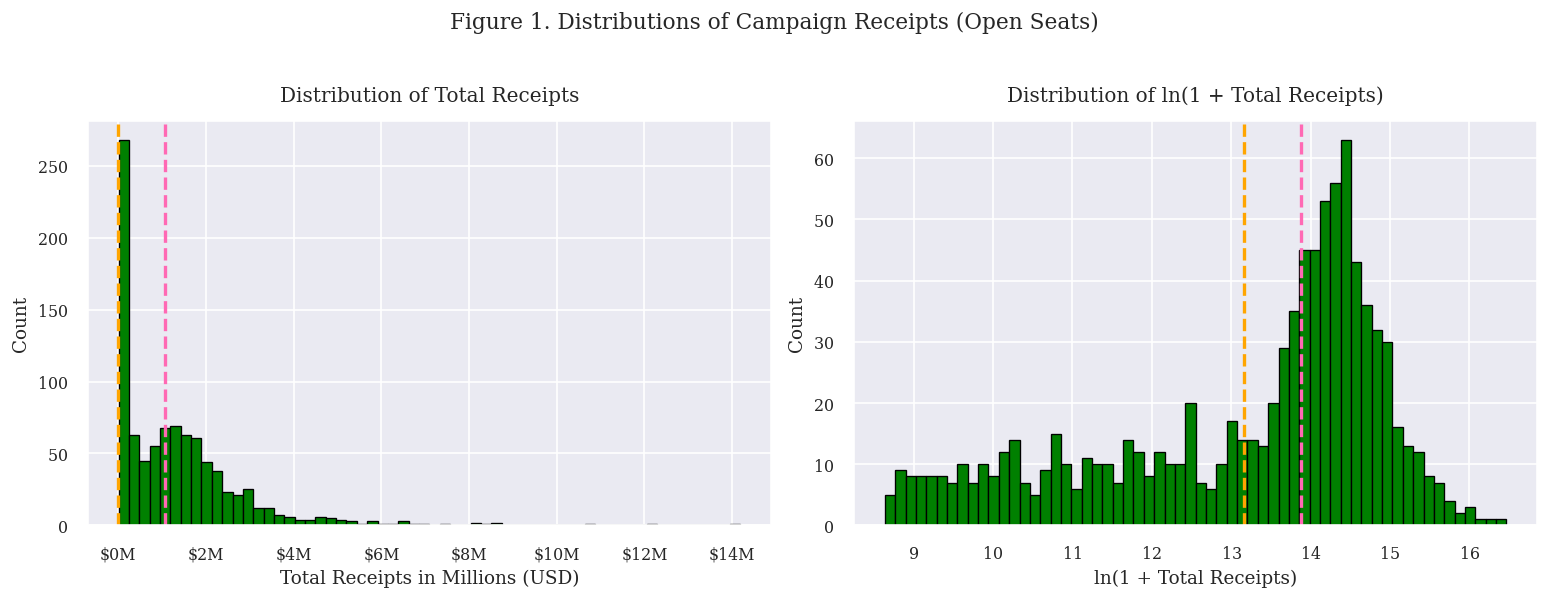

In [18]:
from matplotlib.ticker import FuncFormatter

receipts = house['ttl_receipts'].dropna()
log_receipts = house['log1p_ttl_receipts'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].hist(receipts, bins=60, edgecolor='black', color='green')
ax[0].axvline(receipts.median(), linestyle='--', linewidth=2, color='#FF69B4')
ax[0].axvline(log_receipts.mean(), linestyle='--', linewidth=2, color='orange')
ax[0].set_title('Distribution of Total Receipts')
ax[0].set_xlabel('Total Receipts in Millions (USD)')
ax[0].set_ylabel('Count')
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

ax[1].hist(log_receipts, bins=60, edgecolor='black', color='green')
ax[1].axvline(log_receipts.median(), linestyle='--', linewidth=2, color='#FF69B4')
ax[1].axvline(log_receipts.mean(), linestyle='--', linewidth=2, color='orange')
ax[1].set_title('Distribution of ln(1 + Total Receipts)')
ax[1].set_xlabel('ln(1 + Total Receipts)')
ax[1].set_ylabel('Count')

plt.suptitle('Figure 1. Distributions of Campaign Receipts (Open Seats)', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

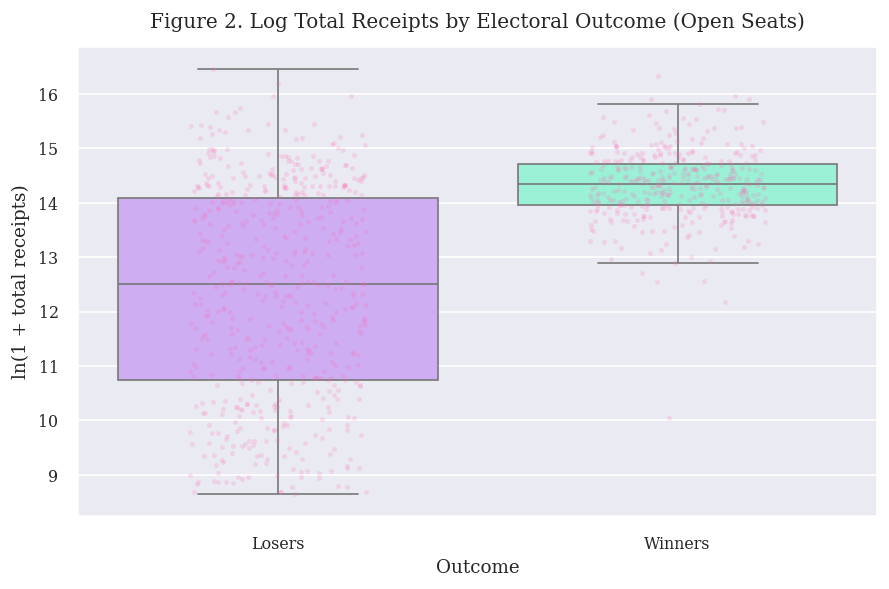

In [19]:
winner_vals = house.loc[house['outcome'] == 1, 'log1p_ttl_receipts'].dropna().to_numpy()
loser_vals = house.loc[house['outcome'] == 0, 'log1p_ttl_receipts'].dropna().to_numpy()

plot_df = house.loc[house['outcome'].isin([0, 1]), ['outcome', 'log1p_ttl_receipts']].copy()
plot_df['Outcome'] = plot_df['outcome'].map({0: 'Losers', 1: 'Winners'})

plt.figure(figsize=(7.5, 5))
sns.boxplot(data=plot_df, x='Outcome', y='log1p_ttl_receipts', palette=['#cea2fd', '#8cffdb'], showfliers=False)
sns.stripplot(data=plot_df, x='Outcome', y='log1p_ttl_receipts', color='#FF69B4', alpha=0.18, size=3, jitter=0.22)

plt.title('Figure 2. Log Total Receipts by Electoral Outcome (Open Seats)')
plt.xlabel('Outcome')
plt.ylabel('ln(1 + total receipts)')
plt.tight_layout()
plt.show()

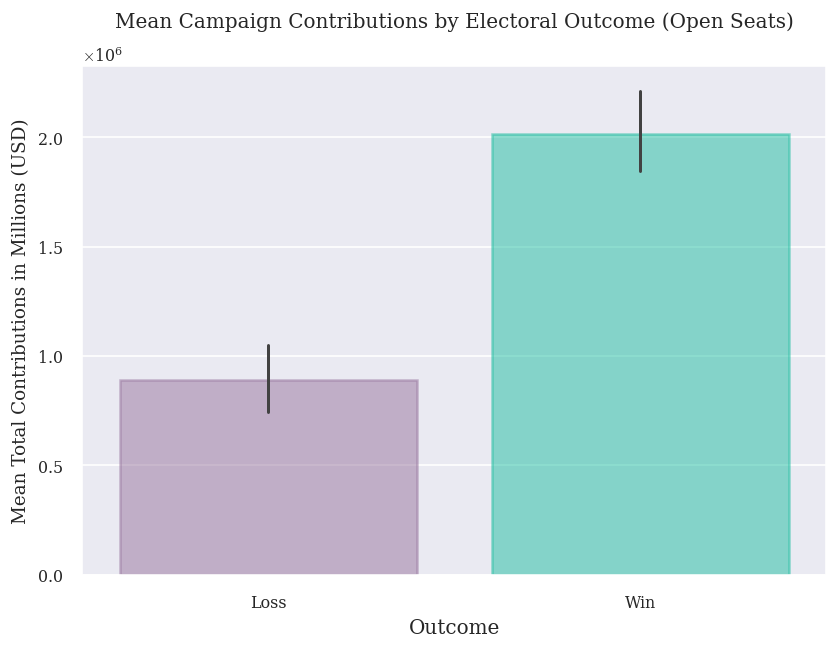

In [20]:
barplot = sns.barplot(data=house, x='outcome', y='ttl_receipts', palette=['#9c6da5','#04d8b2'], errorbar=('ci',99), alpha=0.5)
bars = plt.gca().patches  
for bar in barplot.patches:
    bar_color = bar.get_facecolor()  
    bar.set_edgecolor(bar_color)   
    bar.set_linewidth(1.5)  
plt.title('Mean Campaign Contributions by Electoral Outcome (Open Seats)')
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Mean Total Contributions in Millions (USD)')
plt.xticks(ticks=[0,1], labels=['Loss','Win'])
plt.show()

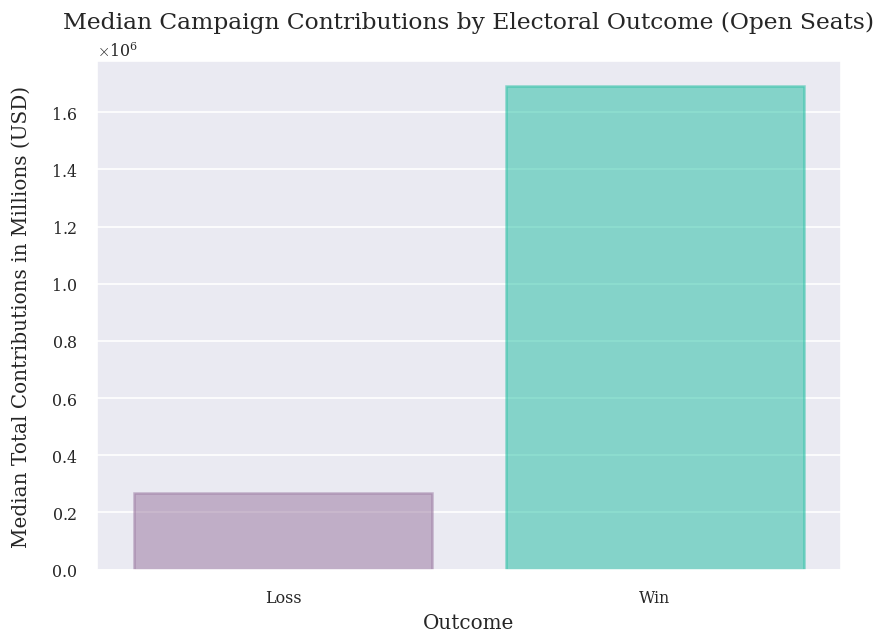

In [21]:
med_rec_by_outcome = [house[house['outcome']==0]['ttl_receipts'].median(), house[house['outcome']==1]['ttl_receipts'].median()]

barplot = sns.barplot(data=pd.DataFrame(med_rec_by_outcome), x=[0,1], y=med_rec_by_outcome, palette=['#9c6da5','#04d8b2'], errorbar=None, alpha=0.5)
bars = plt.gca().patches  
for bar in barplot.patches:
    bar_color = bar.get_facecolor()  
    bar.set_edgecolor(bar_color)   
    bar.set_linewidth(1.5)  
plt.title('Median Campaign Contributions by Electoral Outcome (Open Seats)', fontsize=14, pad=20)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Median Total Contributions in Millions (USD)', labelpad=12, fontsize=12)
plt.xticks(ticks=[0,1], labels=['Loss','Win'])
plt.show()

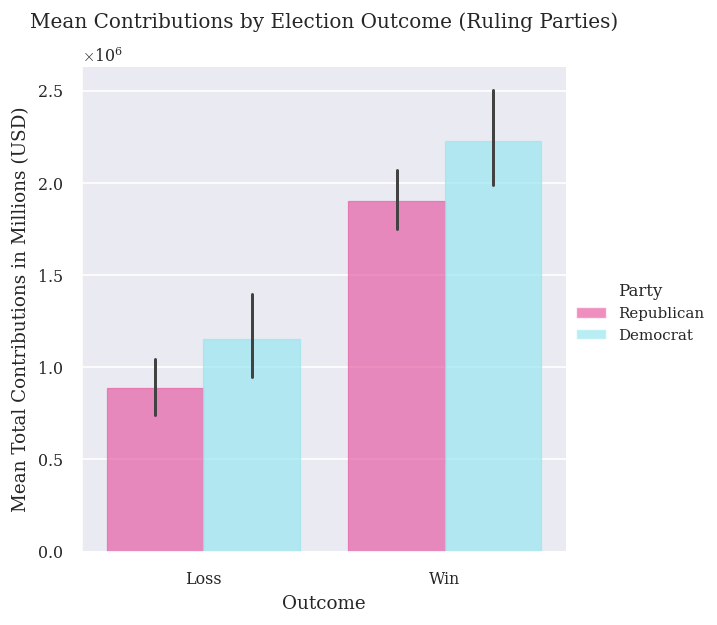

In [22]:
duopoly = house.query("party in ['DEM', 'REP']")

duopoly.rename(columns={'party':'Party'}, inplace=True)

duopoly['Party'] = duopoly['Party'].replace({'REP':'Republican', 'DEM':'Democrat'})

catplot = sns.catplot(data=duopoly, kind='bar', x='outcome', y='ttl_receipts', hue='Party', hue_order=['Republican','Democrat'], palette=['#fe46a5','#8af1fe'], alpha=0.69)
for ax in catplot.axes.flat:
    for bar in ax.patches:  
        bar.set_edgecolor(bar.get_facecolor())  
        bar.set_linewidth(0.75) 
plt.title('Mean Contributions by Election Outcome (Ruling Parties)')
plt.xlabel('Outcome')
plt.ylabel('Mean Total Contributions in Millions (USD)')
plt.xticks(ticks=[0,1], labels=['Loss','Win'])
plt.show()

In [23]:
corr_vars = [
    'vote_share',
    'outcome',
    'log1p_ttl_receipts',
    'burn_rate',
    'cash_ratio',
    'indiv_share',
    'other_cmte_share',
    'party_share',
    'itemized_indiv_share',
    'log1p_total_outside_support',
    'log1p_total_outside_oppose',
    ]

corr = house[corr_vars].corr(method='spearman').round(3)
corr

,vote_share,outcome,log1p_ttl_receipts,burn_rate,cash_ratio,indiv_share,other_cmte_share,party_share,itemized_indiv_share,log1p_total_outside_support,log1p_total_outside_oppose
vote_share,1.000,0.833,0.649,-0.412,0.440,-0.040,0.628,0.015,0.145,0.225,-0.184
outcome,0.833,1.000,0.522,-0.409,0.447,-0.126,0.532,-0.047,0.188,0.221,-0.190
log1p_ttl_receipts,0.649,0.522,1.000,-0.190,0.210,0.035,0.451,0.054,0.162,0.529,0.268
burn_rate,-0.412,-0.409,-0.190,1.000,-0.835,-0.002,-0.260,0.098,-0.062,-0.091,0.147
cash_ratio,0.440,0.447,0.210,-0.835,1.000,0.035,0.272,-0.131,0.037,0.090,-0.177
indiv_share,-0.040,-0.126,0.035,-0.002,0.035,1.000,-0.199,-0.039,-0.288,-0.016,0.031
other_cmte_share,0.628,0.532,0.451,-0.260,0.272,-0.199,1.000,0.217,0.044,0.293,0.009
party_share,0.015,-0.047,0.054,0.098,-0.131,-0.039,0.217,1.000,-0.156,0.082,0.166
itemized_indiv_share,0.145,0.188,0.162,-0.062,0.037,-0.288,0.044,-0.156,1.000,0.085,-0.009
log1p_total_outside_support,0.225,0.221,0.529,-0.091,0.090,-0.016,0.293,0.082,0.085,1.000,0.590


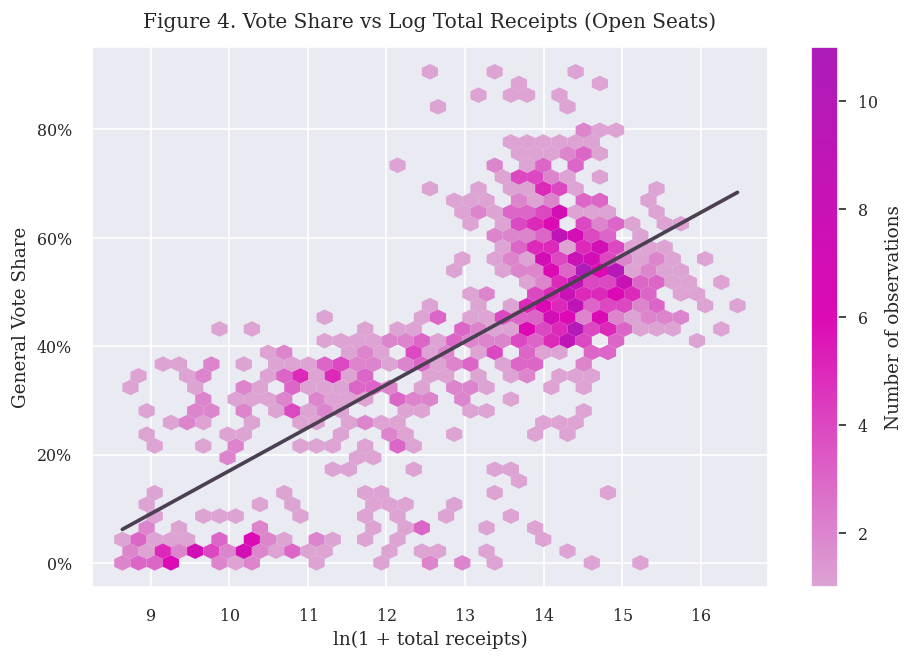

In [25]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mtick

plot_df = house[['log1p_ttl_receipts', 'vote_share']].dropna()

hex_cmap = LinearSegmentedColormap.from_list('campaign_hex', ['#dca3d3', '#dc0ab4', '#ac1db8'])

fig, ax = plt.subplots(figsize=(8, 5.6))

hb = ax.hexbin( plot_df['log1p_ttl_receipts'], plot_df['vote_share'], gridsize=38, cmap=hex_cmap, mincnt=1, linewidths=0 )

sns.regplot( data=plot_df, x='log1p_ttl_receipts', y='vote_share', scatter=False, ci=None, line_kws={'color': '#4b3f52', 'linewidth': 2.2}, ax=ax )

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Number of observations')

ax.set_title('Figure 4. Vote Share vs Log Total Receipts (Open Seats)')
ax.set_xlabel('ln(1 + total receipts)')
ax.set_ylabel('General Vote Share')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.show()

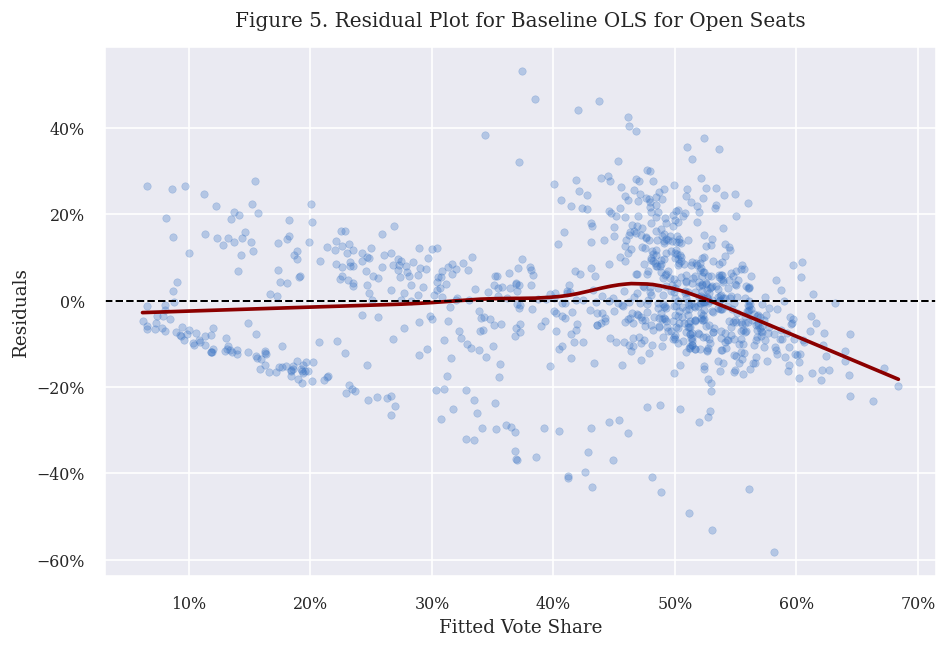

In [27]:
import matplotlib.ticker as mtick

ols_df = house[['vote_share', 'log1p_ttl_receipts']].dropna().copy()
X = sm.add_constant(ols_df['log1p_ttl_receipts'])
y = ols_df['vote_share']
model = sm.OLS(y, X).fit()

resid_df = pd.DataFrame({'Fitted Vote Share': model.fittedvalues, 'Residuals': model.resid})

plt.figure(figsize=(8, 5.5))

sns.scatterplot(data=resid_df, x='Fitted Vote Share', y='Residuals', color='#3873C4', alpha=0.3, s=20, edgecolor=None )

sns.regplot( data=resid_df, x='Fitted Vote Share', y='Residuals', lowess=True, scatter=False, ci=None, line_kws={'color': '#8B0000', 'linewidth': 2.2} )

plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
plt.title('Figure 5. Residual Plot for Baseline OLS for Open Seats')
plt.xlabel('Fitted Vote Share')
plt.ylabel('Residuals')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

__Figure 5__ The residual plot for the baseline regression of vote share on log total receipts reveals substantial structure remaining in the error. While the distinctive wedge-shaped pattern is mostly determined by the bounded nature of vote share, the visible curvature and variable dispersion indicate that campaign receipts alone do not fully capture observed variation in electoral performance.

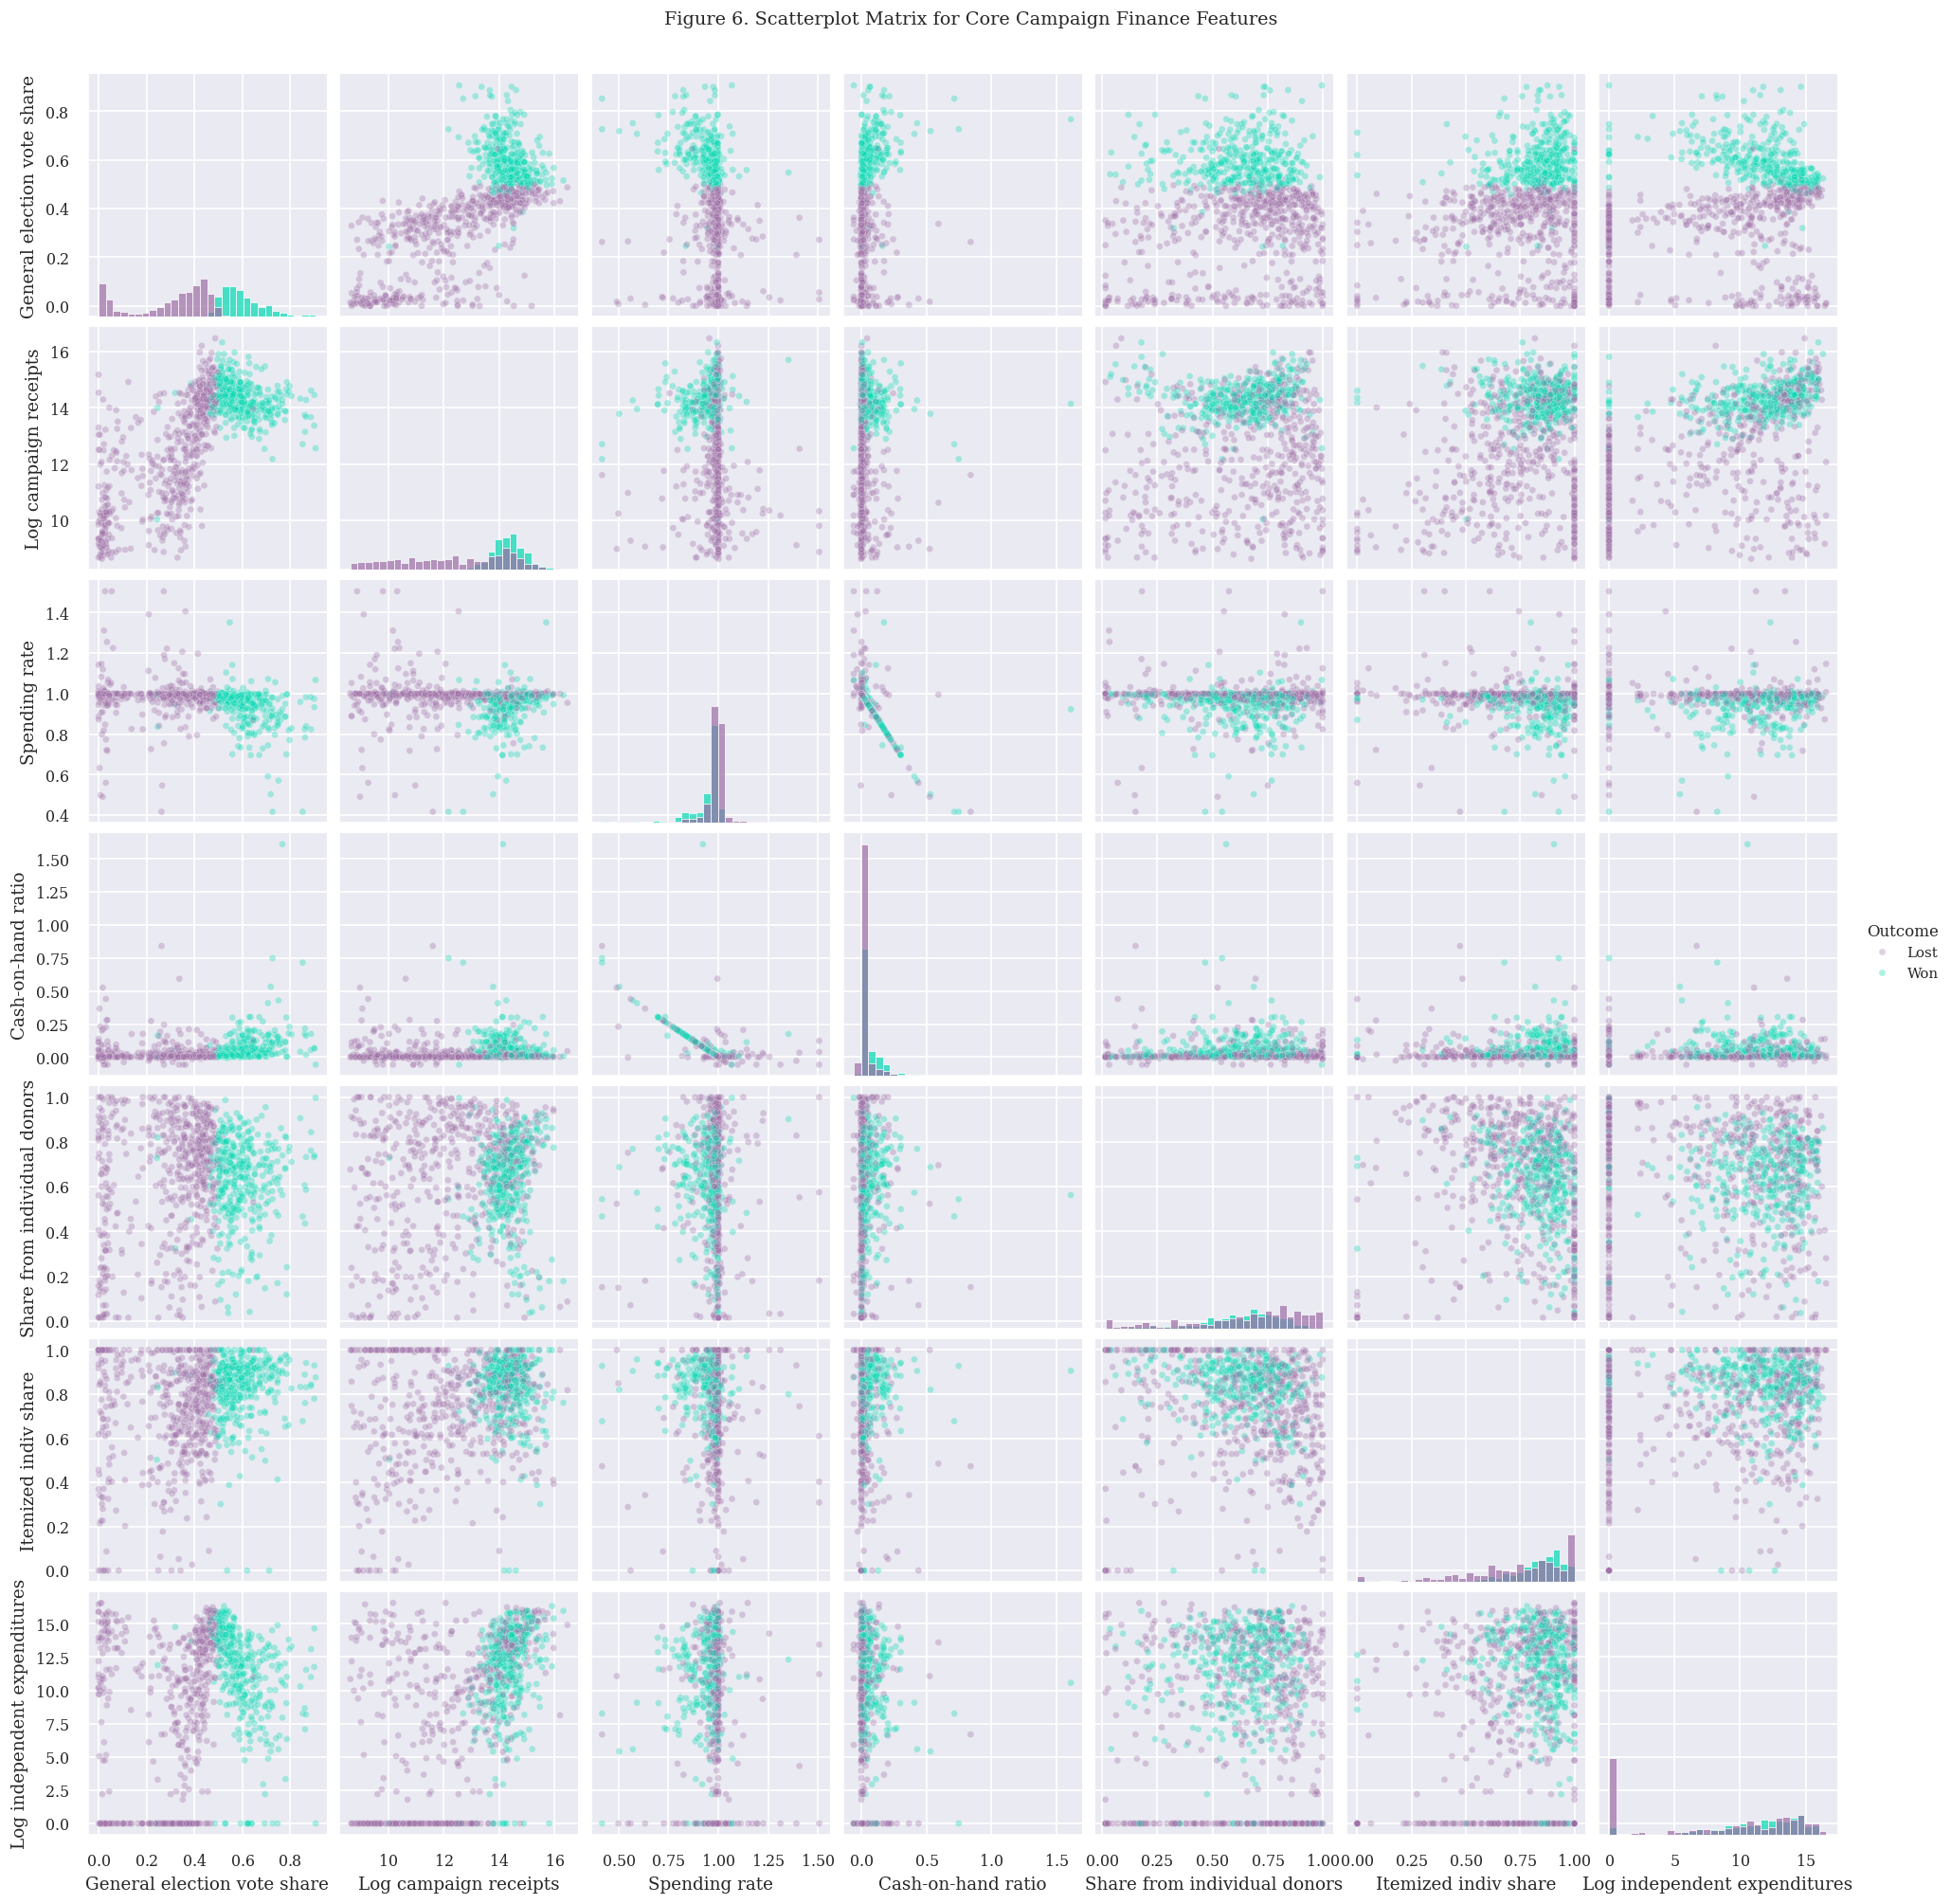

In [28]:
pair_df = house[['vote_share', 'log1p_ttl_receipts', 'burn_rate', 'cash_ratio', 'indiv_share', 'itemized_indiv_share', 'log1p_total_outside_support', 'outcome']].dropna().copy()
if len(pair_df) > 2500:
    pair_df = pair_df.sample(2500, random_state=577)

pair_df['Outcome'] = pair_df['outcome'].map({0: 'Lost', 1: 'Won'})
pair_df = pair_df.rename(columns={
    'vote_share': 'General election vote share',
    'log1p_ttl_receipts': 'Log campaign receipts',
    'burn_rate': 'Spending rate',
    'cash_ratio': 'Cash-on-hand ratio',
    'indiv_share': 'Share from individual donors',
    'itemized_indiv_share' : 'Itemized indiv share',
    'log1p_total_outside_support': 'Log independent expenditures'
    }).drop(columns='outcome')

g = sns.pairplot( pair_df, hue='Outcome', diag_kind='hist', palette=['#9c6da5', '#04d8b2'], plot_kws={'alpha': 0.32, 's': 18}, diag_kws={'bins': 30, 'alpha': 0.7}, height=2.35 )

g.figure.suptitle('Figure 6. Scatterplot Matrix for Core Campaign Finance Features', y=1.02)
plt.show()

__Figure 6__ The scatterplot matrix on several key features reveals several clear pattern: The strongest and most orderly relationship is between **general election vote share** and **log total campaign receipts**. Candidates with larger receipt totals tend, on the average, to receive a larger share of the vote, and the distributions also show a visible shift in receipts between winners and losers. At an elementary descriptive level, campaign scale appears to be the single clearest financial correlate of electoral performance in the present sample.

However, it should be noted that panels involving **vote share** and **election result** are largely tautological, since outcome is entirely determined by vote share in a first-past-the-post contest. Likewise, some of the more striking relationships among the engineered finance variables, especially those involving **spending rate (or burn rate)** and **cash-on-hand ratio**, likely reflect accounting structure in addition to any underlying political phenomenon. These variables are constructed from related financial quantities, so strong geometric patterns between them may indicate partial algebraic dependence rather than genuinely distinct dimensions of campaign behavior.

The matrix also suggests that some variables may be more informative than others. **Log total campaign receipts** appears to contain substantial signal, while variables such as **share from individual donors** exhibit more diffuse and less obviously monotone relationships with electoral performance. This does not necessarily imply that these features are unimportant, but it does suggest that they may be acting via more complicated mechanisms or may be proxies for candidate type, strategy, or race context rather than exerting a simple direct effect on vote share.

Overall, the matrix supports two preliminary conclusions: First, campaign finance variables do appear to carry meaningful information about electoral outcomes, especially measures of overall campaign scale. Second, several engineered ratios display strong internal structure that warrants caution in later modeling, since they may be partially redundant or mechanically related. This argues for proceeding with a parsimonious initial regression specification before moving to broader multivariate or machine learning models.

In [29]:
reg_df = house[['vote_share', 'log1p_ttl_receipts', 'party']].dropna().copy()
reg_df['party_group'] = np.where(reg_df['party'].isin(['DEM', 'REP']), reg_df['party'], 'OTH')

X = pd.concat([
    reg_df[['log1p_ttl_receipts']].astype(float),
    pd.get_dummies(reg_df['party_group'], prefix='pty', dtype=float).drop(columns='pty_OTH')
], axis=1)

X = sm.add_constant(X)
y = reg_df['vote_share'].astype(float)

model1 = sm.OLS(y, X).fit(cov_type='HC3')

term_labels = {
    'const': 'Intercept',
    'log1p_ttl_receipts': 'ln(1 + total receipts)',
    'pty_DEM': 'Democrat',
    'pty_REP': 'Republican'
}

reg_table = pd.DataFrame({
    'Term': [term_labels.get(term, term) for term in model1.params.index],
    'Coefficient': model1.params.values,
    'Robust SE': model1.bse.values,
    'z': model1.tvalues.values,
    'p-value': model1.pvalues.values})

reg_table['Coefficient'] = reg_table['Coefficient'].map(lambda x: f'{x:.4f}')
reg_table['Robust SE'] = reg_table['Robust SE'].map(lambda x: f'({x:.4f})')
reg_table['z'] = reg_table['z'].map(lambda x: f'{x:.2f}')
reg_table['p-value'] = reg_table['p-value'].map(lambda x: '<0.001' if x < 0.001 else f'{x:.3f}')

model_stats = pd.DataFrame({
    'Term': ['N', 'R²', 'Adj. R²'],
    'Coefficient': [f'{int(model1.nobs):,}', f'{model1.rsquared:.3f}', f'{model1.rsquared_adj:.3f}'],
    'Robust SE': ['', '', ''],
    'z': ['', '', ''],
    'p-value': ['', '', '']})

reg_table = pd.concat([reg_table, model_stats], ignore_index=True)

print('Table 4. Baseline OLS Regression of Vote Share')
display(reg_table)
print('Reference categories: Challenger and OTH. Robust standard errors are HC3.')
reg_table.to_csv('figures/Table 4.csv')

Table 4. Baseline OLS Regression of Vote Share


,Term,Coefficient,Robust SE,z,p-value
0,Intercept,-0.5537,(0.0249),-22.22,<0.001
1,ln(1 + total receipts),0.0615,(0.0026),23.26,<0.001
2,Democrat,0.1918,(0.0169),11.32,<0.001
3,Republican,0.1953,(0.0175),11.15,<0.001
4,N,926,,,
5,R²,0.599,,,
6,Adj. R²,0.597,,,


Reference categories: Challenger and OTH. Robust standard errors are HC3.


__Table 4__ reports a baseline OLS regression of general election vote share on log total receipts, incumbency, and party affiliation using HC3 heteroskedasticity-robust standard errors. The results indicate that campaign scale remains a strong positive correlate of electoral performance even after controlling for major structural predictors. In paricular, a single unit increase in `ln(1 + total receipts)` is associated with a 0.0318 increase in vote share, implying that a doubling of campaign receipts corresponds to roughly a 2.2 percentage point increase in expected vote share (a highly nontrivial increment in close races).

Importantly, incumbency is very strongly associated with electoral performance. Relative to challengers, incumbents receive substantially higher predicted vote share, while open seat contenders also outperform challengers by a smaller but nevertheless meaningful margin. Party effects are likewise large: Democratic and Republican candidates both consistently outperform third party candidates, reflecting the dominant position of the two ruling parties in U.S. federal general elections.

Overall, the model explains a large share of the variation in vote share (R² = 0.704), suggesting that campaign scale, incumbency, and party together provide a strong baseline account of electoral outcomes in the present dataset.

### Citizens United 

Because this notebook pools House elections across multiple cycles, it may be useful to examine whether the campaign-finance environment changes over time before deciding how to treat cycle in the regression models. This is especially important around the 2010–2012 phase transition associated with the Citizens United decision and the expansion of overall outside spending activity.

The following marginal checks summarize total outside support, outside opposition, and coordinated party expenditures by cycle and by broad pre-/post-Citizens United period. These displays are descriptive rather than causal in that they do not identify the effect of the decision itself, and the outside spending variables are race-contextual proxies rather than a complete measure of all political money in each race; their purpose is to show whether the pooled dataset contains enough temporal variation to warrant a later cycle-fixed-effects robustness check. Moreover, since the independent expenditure variables are already candidate-level, race-contextual aggregates, raw cycle sums are sensitive to how many candidate-contest rows are represented in a given cycle (which is in turn determined by the FEC's bulk data coverage and integrity for any given cycle vis a vis how candidate summary data can be merged on committee contributions and independent expenditures). Independent expenditures are therefore normalized by all represented candidate-contest rows. Coordinated party expenditures are treated differently because only a minority (about a quarter) of candidate-contest rows have positive recorded coordinated party expenditures. For that series, I report spending intensity among candidate-contest rows with positive recorded coordinated party spending.

This section is only a rough descriptive check of whether the analytic House dataset preserves the familiar post-2010 increase in independent spending. The quantities below should not be read as official spending totals. The resulting figure is therefore best read as a descriptive comparison of **candidate-normalized independent spending** and **conditional coordinated party spending**, not as a comparison of official aggregate totals. Note however the striking directional agreement with the displays appearing on, e.g., https://www.opensecrets.org/news/reports/a-decade-under-citizens-united.

These plots motivate __Model 5__ below, which adds categorical cycle fixed effects to the richest full sample OLS specification. __Model 5__ is interpreted as a retrospective robustness check, not as a candidate specification for the later temporally held-out prediction task.


In [30]:
contest_cols = ["cycle", "state", "district"]
spend_cols = ["ind_exp_support", "ind_exp_oppose", "party_coord_exp"]

cu_df = house[contest_cols + ["cand_id"] + spend_cols].copy()

cu_df["cycle"] = pd.to_numeric(cu_df["cycle"], errors="raise").astype(int)
cu_df["district"] = pd.to_numeric(cu_df["district"], errors="raise")

for col in spend_cols:
    cu_df[col] = pd.to_numeric(cu_df[col], errors="coerce").fillna(0)

cu_df["ind_exp_total"] = cu_df["ind_exp_support"] + cu_df["ind_exp_oppose"]

represented_contests = (
    cu_df
    .drop_duplicates(contest_cols)
    .groupby("cycle")
    .size()
    .rename("represented_contests")
)

cu_by_cycle = (
    cu_df
    .groupby("cycle")
    .agg(
        candidate_contests=("cand_id", "size"),
        party_spending_candidate_contests=("party_coord_exp", lambda x: (x > 0).sum()),
        ind_exp_total=("ind_exp_total", "sum"),
        party_coord_exp=("party_coord_exp", "sum")
    )
    .join(represented_contests)
    .assign(
        candidates_per_contest=lambda x: x["candidate_contests"] / x["represented_contests"],
        party_spending_share=lambda x: x["party_spending_candidate_contests"] / x["candidate_contests"],
        ind_exp_per_candidate_contest=lambda x: x["ind_exp_total"] / x["candidate_contests"],
        party_coord_exp_per_spending_candidate_contest=lambda x: x["party_coord_exp"] / x["party_spending_candidate_contests"]
    )
)

cu_by_cycle["party_coord_exp_per_spending_candidate_contest"] = (
    cu_by_cycle["party_coord_exp_per_spending_candidate_contest"]
    .replace([np.inf, -np.inf], np.nan)
)

In [31]:
cu_cycle_display = (
    cu_by_cycle
    .assign(
        ind_exp_total_m=lambda x: x["ind_exp_total"] / 1_000_000,
        party_coord_exp_m=lambda x: x["party_coord_exp"] / 1_000_000,
        ind_exp_per_candidate_contest_k=lambda x: x["ind_exp_per_candidate_contest"] / 1_000,
        party_coord_exp_per_spending_candidate_contest_k=lambda x: x["party_coord_exp_per_spending_candidate_contest"] / 1_000
    )[[
        "candidate_contests",
        "represented_contests",
        "candidates_per_contest",
        "party_spending_candidate_contests",
        "party_spending_share",
        "ind_exp_total_m",
        "party_coord_exp_m",
        "ind_exp_per_candidate_contest_k",
        "party_coord_exp_per_spending_candidate_contest_k"
    ]]
    .rename(columns={
        "candidate_contests": "Candidate-contest rows",
        "represented_contests": "Represented contests",
        "candidates_per_contest": "Rows per contest",
        "party_spending_candidate_contests": "Rows with coord. party exp.",
        "party_spending_share": "Share with coord. party exp.",
        "ind_exp_total_m": "Independent expenditures ($M)",
        "party_coord_exp_m": "Coordinated party expenditures ($M)",
        "ind_exp_per_candidate_contest_k": "Independent exp. per candidate-contest ($K)",
        "party_coord_exp_per_spending_candidate_contest_k": "Coord. party exp. per positive row ($K)"
    })
)

cu_cycle_display.round(3)

,Candidate-contest rows,Represented contests,Rows per contest,Rows with coord. party exp.,Share with coord. party exp.,Independent expenditures ($M),Coordinated party expenditures ($M),Independent exp. per candidate-contest ($K),Coord. party exp. per positive row ($K)
cycle,,,,,,,,,
2004,97,55,1.764,28,0.289,98.595,1.598,1016.448,57.087
2006,69,32,2.156,34,0.493,83.603,3.772,1211.632,110.929
2008,99,46,2.152,45,0.455,103.354,3.002,1043.979,66.704
2010,90,38,2.368,32,0.356,74.513,1.727,827.921,53.972
2012,80,48,1.667,28,0.350,78.860,1.774,985.755,63.343
2014,99,43,2.302,26,0.263,91.180,2.103,921.007,80.869
2016,90,45,2.000,27,0.300,187.437,2.124,2082.630,78.651
2018,126,65,1.938,51,0.405,335.390,4.062,2661.827,79.651
2020,79,39,2.026,27,0.342,259.581,1.969,3285.835,72.942


In [32]:
cu_period_by_cycle = cu_by_cycle.reset_index().copy()

cu_period_by_cycle["period"] = pd.Categorical(
    np.select(
        [
            cu_period_by_cycle["cycle"].le(2008),
            cu_period_by_cycle["cycle"].eq(2010),
            cu_period_by_cycle["cycle"].ge(2012)
        ],
        ["Pre-CU", "2010 transition", "Post-CU"],
        default=pd.NA
    ),
    categories=["Pre-CU", "2010 transition", "Post-CU"],
    ordered=True
)

cu_period_display = (
    cu_period_by_cycle
    .groupby("period", observed=True)
    .agg(
        first_cycle=("cycle", "min"),
        last_cycle=("cycle", "max"),
        candidate_contests=("candidate_contests", "sum"),
        represented_contests=("represented_contests", "sum"),
        party_spending_candidate_contests=("party_spending_candidate_contests", "sum"),
        ind_exp_total=("ind_exp_total", "sum"),
        party_coord_exp=("party_coord_exp", "sum")
    )
    .assign(
        candidates_per_contest=lambda x: x["candidate_contests"] / x["represented_contests"],
        party_spending_share=lambda x: x["party_spending_candidate_contests"] / x["candidate_contests"],
        ind_exp_total_m=lambda x: x["ind_exp_total"] / 1_000_000,
        party_coord_exp_m=lambda x: x["party_coord_exp"] / 1_000_000,
        ind_exp_per_candidate_contest_k=lambda x: x["ind_exp_total"] / x["candidate_contests"] / 1_000,
        party_coord_exp_per_spending_candidate_contest_k=lambda x: x["party_coord_exp"] / x["party_spending_candidate_contests"] / 1_000
    )[[
        "first_cycle",
        "last_cycle",
        "candidate_contests",
        "represented_contests",
        "candidates_per_contest",
        "party_spending_candidate_contests",
        "party_spending_share",
        "ind_exp_total_m",
        "party_coord_exp_m",
        "ind_exp_per_candidate_contest_k",
        "party_coord_exp_per_spending_candidate_contest_k"
    ]]
    .rename(columns={
        "first_cycle": "First cycle",
        "last_cycle": "Last cycle",
        "candidate_contests": "Candidate-contest rows",
        "represented_contests": "Represented contests",
        "candidates_per_contest": "Rows per contest",
        "party_spending_candidate_contests": "Rows with coord. party exp.",
        "party_spending_share": "Share with coord. party exp.",
        "ind_exp_total_m": "Independent expenditures ($M)",
        "party_coord_exp_m": "Coordinated party expenditures ($M)",
        "ind_exp_per_candidate_contest_k": "Independent exp. per candidate-contest ($K)",
        "party_coord_exp_per_spending_candidate_contest_k": "Coord. party exp. per positive row ($K)"
    })
)

cu_period_display.round(3)

,First cycle,Last cycle,Candidate-contest rows,Represented contests,Rows per contest,Rows with coord. party exp.,Share with coord. party exp.,Independent expenditures ($M),Coordinated party expenditures ($M),Independent exp. per candidate-contest ($K),Coord. party exp. per positive row ($K)
period,,,,,,,,,,,
Pre-CU,2004,2008,265,133,1.992,107,0.404,285.552,8.372,1077.555,78.240
2010 transition,2010,2010,90,38,2.368,32,0.356,74.513,1.727,827.921,53.972
Post-CU,2012,2022,571,295,1.936,195,0.342,1321.525,14.901,2314.405,76.415


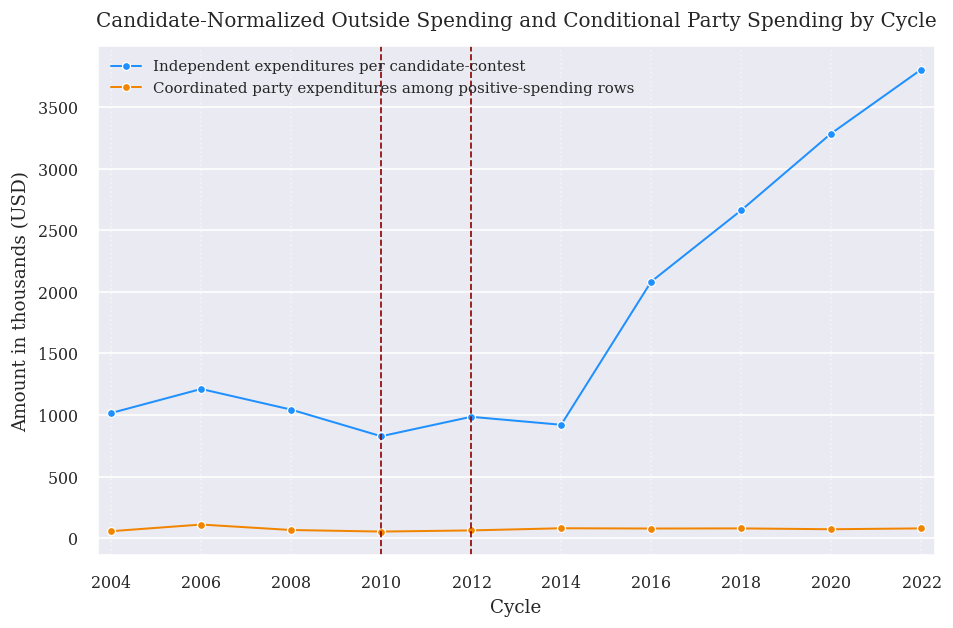

In [33]:
cu_norm_plot = (
    cu_by_cycle
    .reset_index()
    .assign(
        ind_exp_per_candidate_contest_k=lambda x: x["ind_exp_per_candidate_contest"] / 1_000,
        party_coord_exp_per_spending_candidate_contest_k=lambda x: x["party_coord_exp_per_spending_candidate_contest"] / 1_000
    )
    .melt(
        id_vars="cycle",
        value_vars=[
            "ind_exp_per_candidate_contest_k",
            "party_coord_exp_per_spending_candidate_contest_k"
        ],
        var_name="measure",
        value_name="amount_k"
    )
)

cu_norm_plot["measure"] = cu_norm_plot["measure"].replace({
    "ind_exp_per_candidate_contest_k": "Independent expenditures per candidate-contest",
    "party_coord_exp_per_spending_candidate_contest_k": "Coordinated party expenditures among positive-spending rows"
})

cycle_ticks = sorted(cu_norm_plot["cycle"].unique())

plt.figure(figsize=(9, 5.5))
sns.lineplot(
    data=cu_norm_plot,
    x="cycle",
    y="amount_k",
    hue="measure",
    marker="o",
    palette=["dodgerblue", "#F28500"]
)

plt.xticks(cycle_ticks)
plt.xlim(min(cycle_ticks) - 0.3, max(cycle_ticks) + 0.3)
plt.axvline(2010, linestyle="--", linewidth=1, color="#8B0000")
plt.axvline(2012, linestyle="--", linewidth=1, color="#8B0000")

plt.title("Candidate-Normalized Outside Spending and Conditional Party Spending by Cycle", pad=12)
plt.xlabel("Cycle")
plt.ylabel("Amount in thousands (USD)")
plt.legend(title="")
plt.grid(axis="x", linestyle=":", alpha=0.5)
plt.show()

# Regression Analyses

Because the open seat subset removes the dominant incumbency structure present in the full House dataset, this section proceeds immediately to fit the full M4 model as the main benchmark and then compare it against a nonlinear kernel ridge model fit on the same feature set, as well as an OLS regression on the reduced model produced by the feature selection step of the preliminary analysis. 

### Data Prep and Helper Functions

In [ ]:
main_regressors = [
    "party_model",
    "log1p_ttl_receipts",
    "cash_ratio",
    "indiv_share",
    "other_cmte_share",
    "party_share",
    "itemized_indiv_share",
    "log1p_total_outside_support",
    "log1p_total_outside_oppose",
    "log1p_party_coord_exp"
]

reduced_regressors = [
    "party_model",
    "log1p_ttl_receipts",
    "cash_ratio",
    "other_cmte_share",
    "log1p_total_outside_support",
    "log1p_total_outside_oppose"
]

regression_cols = [
    "vote_share",
    "party",
    "log1p_ttl_receipts",
    "cash_ratio",
    "indiv_share",
    "other_cmte_share",
    "party_share",
    "itemized_indiv_share",
    "log1p_total_outside_support",
    "log1p_total_outside_oppose",
    "log1p_party_coord_exp"
]

missing_cols = [col for col in regression_cols if col not in house.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

open_reg_df = house[regression_cols].copy()

open_reg_df["party_model"] = np.where(
    open_reg_df["party"].isin(["DEM", "REP"]),
    open_reg_df["party"],
    "OTH"
)

numeric_cols = [col for col in regression_cols if col != "party"]

for col in numeric_cols:
    open_reg_df[col] = pd.to_numeric(open_reg_df[col], errors="coerce")

open_reg_df = open_reg_df.dropna(subset=["vote_share", *main_regressors]).copy()
open_reg_df["party_model"] = pd.Categorical(open_reg_df["party_model"], categories=["OTH", "DEM", "REP"])

open_reg_df.shape

(926, 12)

In [51]:
def make_design(data, regressors):
    X_parts = []

    if "party_model" in regressors:
        party_dummies = pd.get_dummies(data["party_model"], prefix="party", dtype=float).drop(columns="party_OTH", errors="ignore")
        X_parts.append(party_dummies)

    numeric_terms = [x for x in regressors if x != "party_model"]
    X_parts.append(data[numeric_terms].astype(float))

    X = pd.concat(X_parts, axis=1)
    X = sm.add_constant(X)

    y = data["vote_share"].astype(float)

    return X, y

def fit_open_model(data, regressors):
    X, y = make_design(data, regressors)
    model = sm.OLS(y, X).fit(cov_type="HC3")
    return model

def model_summary_row(model, label):
    resid = model.resid

    return pd.DataFrame([{
        "Model": label,
        "N": int(model.nobs),
        "R²": model.rsquared,
        "Adj. R²": model.rsquared_adj,
        "RMSE": np.sqrt(np.mean(resid ** 2)),
        "MAE": np.mean(np.abs(resid)),
        "AIC": model.aic,
        "BIC": model.bic
    }])

def coef_table(model, label):
    return pd.DataFrame({
        "Model": label,
        "Term": model.params.index,
        "Coefficient": model.params.values,
        "Robust SE": model.bse.values,
        "Statistic": model.tvalues.values,
        "p-value": model.pvalues.values
    })

def leverage_summary(model, model_name):
    hat = model.get_influence().hat_matrix_diag
    n = int(model.nobs)
    p = int(model.df_model + 1)

    return pd.DataFrame([{
        "model": model_name,
        "n": n,
        "p": p,
        "p/n": p / n,
        "mean_hat": hat.mean(),
        "max_hat": hat.max(),
        "n_hat_gt_2p_n": (hat > 2 * p / n).sum(),
        "n_hat_gt_3p_n": (hat > 3 * p / n).sum(),
        "pct_hat_gt_2p_n": (hat > 2 * p / n).mean(),
        "pct_hat_gt_3p_n": (hat > 3 * p / n).mean()
    }])

def residual_summary(model, model_name):
    return pd.DataFrame([{
        "model": model_name,
        "mean_resid": model.resid.mean(),
        "sd_resid": model.resid.std(),
        "min_resid": model.resid.min(),
        "q1_resid": model.resid.quantile(0.25),
        "median_resid": model.resid.median(),
        "q3_resid": model.resid.quantile(0.75),
        "max_resid": model.resid.max()
    }])

def residual_diagnostic_plots(model, model_name, sample_size=3000):
    resid_df = pd.DataFrame({
        "fitted": model.fittedvalues,
        "resid": model.resid
    })

    if len(resid_df) > sample_size:
        plot_df = resid_df.sample(sample_size, random_state=577)
    else:
        plot_df = resid_df

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    sns.scatterplot(data=plot_df, x="fitted", y="resid", alpha=0.3, s=18, ax=axes[0])

    sns.regplot(
        data=resid_df,
        x="fitted",
        y="resid",
        lowess=True,
        scatter=False,
        ci=None,
        line_kws={"color": "#8B0000", "linewidth": 2.2},
        ax=axes[0]
    )

    axes[0].axhline(0, linestyle="--", linewidth=1)
    axes[0].set_title(f"{model_name}: Residuals vs. Fitted")
    axes[0].set_xlabel("Fitted vote share")
    axes[0].set_ylabel("Residual")

    stats.probplot(model.resid, dist="norm", plot=axes[1])
    axes[1].set_title(f"{model_name}: Q-Q Plot")

    plt.tight_layout()
    plt.show()

In [43]:
open_reduced = fit_open_model(open_reg_df, reduced_regressors)
open_main = fit_open_model(open_reg_df, main_regressors)

open_model_comparison = pd.concat([
    model_summary_row(open_reduced, "Reduced open-seat model"),
    model_summary_row(open_main, "Main open-seat model")
], ignore_index=True)

open_model_comparison.round(4)

,Model,N,R²,Adj. R²,RMSE,MAE,AIC,BIC
0,Reduced open-seat model,926,0.7343,0.7322,0.1041,0.0748,-1545.3068,-1506.6598
1,Main open-seat model,926,0.7375,0.7344,0.1035,0.0741,-1548.8361,-1490.8656


In [44]:
term_labels = {
    "const": "Intercept",
    "party_DEM": "Democrat",
    "party_REP": "Republican",
    "log1p_ttl_receipts": "ln(1 + total receipts)",
    "cash_ratio": "Cash ratio",
    "indiv_share": "Individual contribution share",
    "other_cmte_share": "Other committee contribution share",
    "party_share": "Party contribution share",
    "itemized_indiv_share": "Itemized individual contribution share",
    "log1p_total_outside_support": "ln(1 + outside support)",
    "log1p_total_outside_oppose": "ln(1 + outside opposition)",
    "log1p_party_coord_exp": "ln(1 + coordinated party expenditures)"
}

open_coef_table = pd.concat([
    coef_table(open_reduced, "Reduced open-seat model"),
    coef_table(open_main, "Main open-seat model")
], ignore_index=True)

open_coef_display = open_coef_table.copy()
open_coef_display["Term"] = open_coef_display["Term"].replace(term_labels)
open_coef_display["Coefficient"] = open_coef_display["Coefficient"].map(lambda x: f"{x:.4f}")
open_coef_display["Robust SE"] = open_coef_display["Robust SE"].map(lambda x: f"({x:.4f})")
open_coef_display["Statistic"] = open_coef_display["Statistic"].map(lambda x: f"{x:.2f}")
open_coef_display["p-value"] = open_coef_display["p-value"].map(lambda x: "<0.001" if x < 0.001 else f"{x:.3f}")

open_coef_display

,Model,Term,Coefficient,Robust SE,Statistic,p-value
0,Reduced open-seat model,Intercept,-0.4007,(0.0309),-12.97,<0.001
1,Reduced open-seat model,Democrat,0.1571,(0.0163),9.65,<0.001
2,Reduced open-seat model,Republican,0.1655,(0.0167),9.92,<0.001
3,Reduced open-seat model,ln(1 + total receipts),0.0562,(0.0032),17.60,<0.001
4,Reduced open-seat model,Cash ratio,0.1947,(0.0695),2.80,0.005
5,Reduced open-seat model,Other committee contribution share,0.2724,(0.0288),9.45,<0.001
6,Reduced open-seat model,ln(1 + outside support),0.0007,(0.0010),0.76,0.446
7,Reduced open-seat model,ln(1 + outside opposition),-0.0115,(0.0009),-13.18,<0.001
8,Main open-seat model,Intercept,-0.4557,(0.0390),-11.68,<0.001
9,Main open-seat model,Democrat,0.1490,(0.0174),8.58,<0.001


In [ ]:
open_coef_wide = (
    open_coef_table
    .assign(Term=lambda x: x["Term"].replace(term_labels))
    .pivot(index="Term", columns="Model", values="Coefficient")
)

open_coef_wide.round(4)

Model,Main open-seat model,Reduced open-seat model
Term,,
Cash ratio,0.1931,0.1947
Democrat,0.1490,0.1571
Individual contribution share,0.0388,NaN
Intercept,-0.4557,-0.4007
Itemized individual contribution share,0.0059,NaN
Other committee contribution share,0.2953,0.2724
Party contribution share,0.2617,NaN
Republican,0.1595,0.1655
ln(1 + coordinated party expenditures),-0.0014,NaN


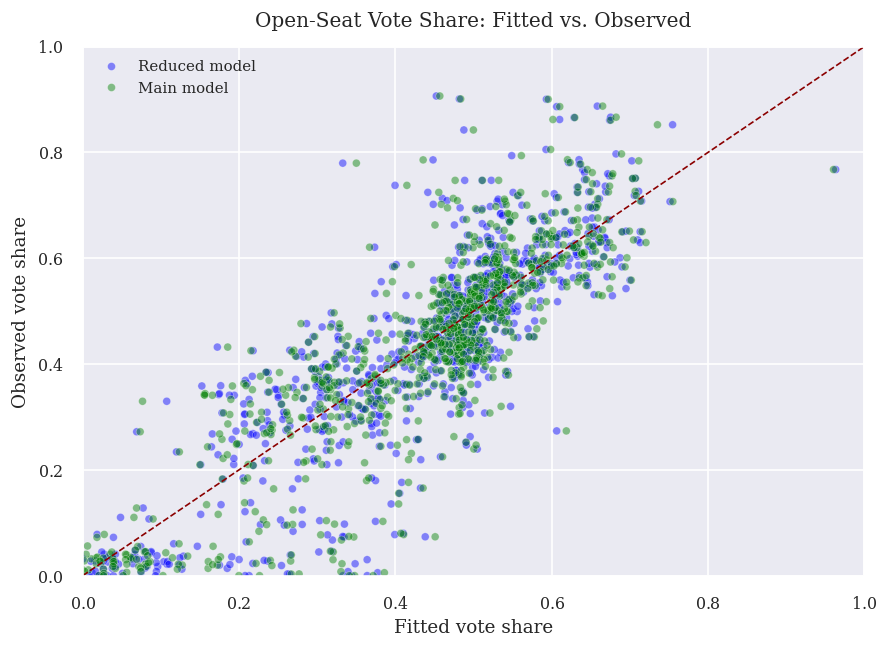

In [49]:
X_reduced, y_open = make_design(open_reg_df, reduced_regressors)
X_main, _ = make_design(open_reg_df, main_regressors)

open_pred_df = open_reg_df[["vote_share"]].copy()
open_pred_df["Reduced model"] = open_reduced.predict(X_reduced)
open_pred_df["Main model"] = open_main.predict(X_main)

open_pred_long = (open_pred_df .melt( id_vars="vote_share", value_vars=["Reduced model", "Main model"], var_name="Model", value_name="Fitted vote share"))

plt.figure(figsize=(7.5, 5.5))

sns.scatterplot(data=open_pred_long, x="Fitted vote share", y="vote_share", hue="Model", palette=['blue','green'], alpha=0.45)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="#8B0000")
plt.title("Open-Seat Vote Share: Fitted vs. Observed", pad=12)
plt.xlabel("Fitted vote share")
plt.ylabel("Observed vote share")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(title="")
plt.tight_layout()
plt.show()

In [54]:
open_residual_summary = pd.concat([residual_summary(open_reduced, "Reduced open-seat model"), residual_summary(open_main, "Main open-seat model")], ignore_index=True)

open_residual_summary.round(4)

,model,mean_resid,sd_resid,min_resid,q1_resid,median_resid,q3_resid,max_resid
0,Reduced open-seat model,-0.0,0.1042,-0.3717,-0.0516,0.0004,0.0528,0.4542
1,Main open-seat model,0.0,0.1036,-0.3803,-0.0518,0.0016,0.0526,0.4497


In [ ]:
open_leverage_summary = pd.concat([leverage_summary(open_reduced, "Reduced open-seat model"), leverage_summary(open_main, "Main open-seat model")], ignore_index=True)

open_leverage_summary.round(4)

,model,n,p,p/n,mean_hat,max_hat,n_hat_gt_2p_n,n_hat_gt_3p_n,pct_hat_gt_2p_n,pct_hat_gt_3p_n
0,Reduced open-seat model,926,8,0.0086,0.0086,0.3056,36,12,0.0389,0.0130
1,Main open-seat model,926,12,0.0130,0.0130,0.3077,54,20,0.0583,0.0216


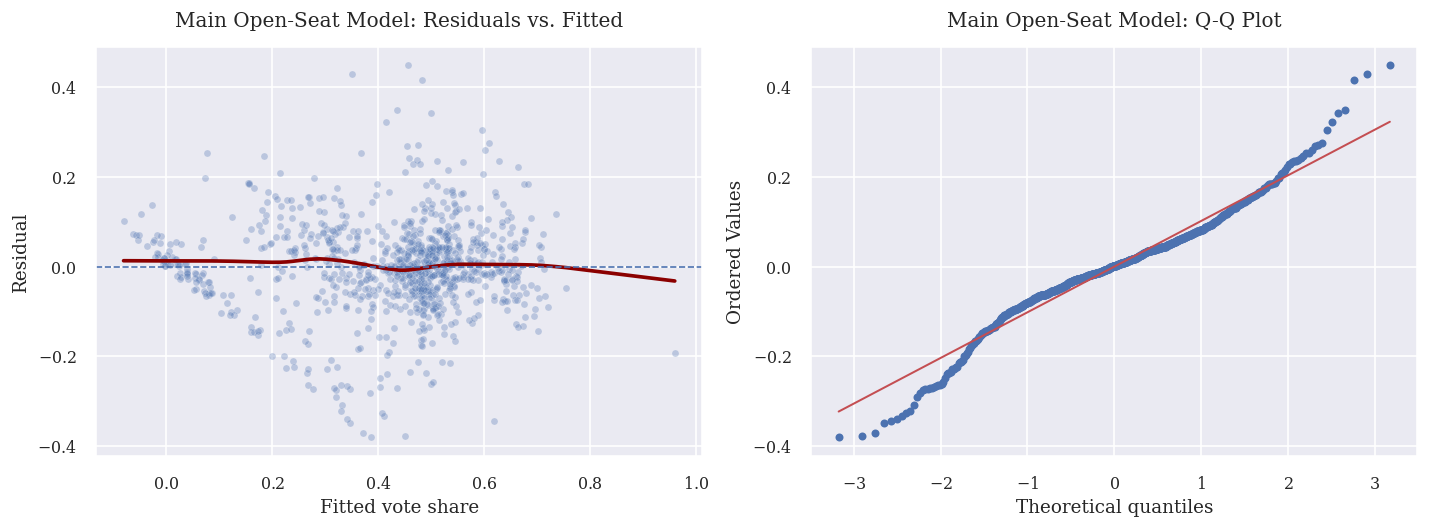

In [56]:
residual_diagnostic_plots(open_main, "Main Open-Seat Model")

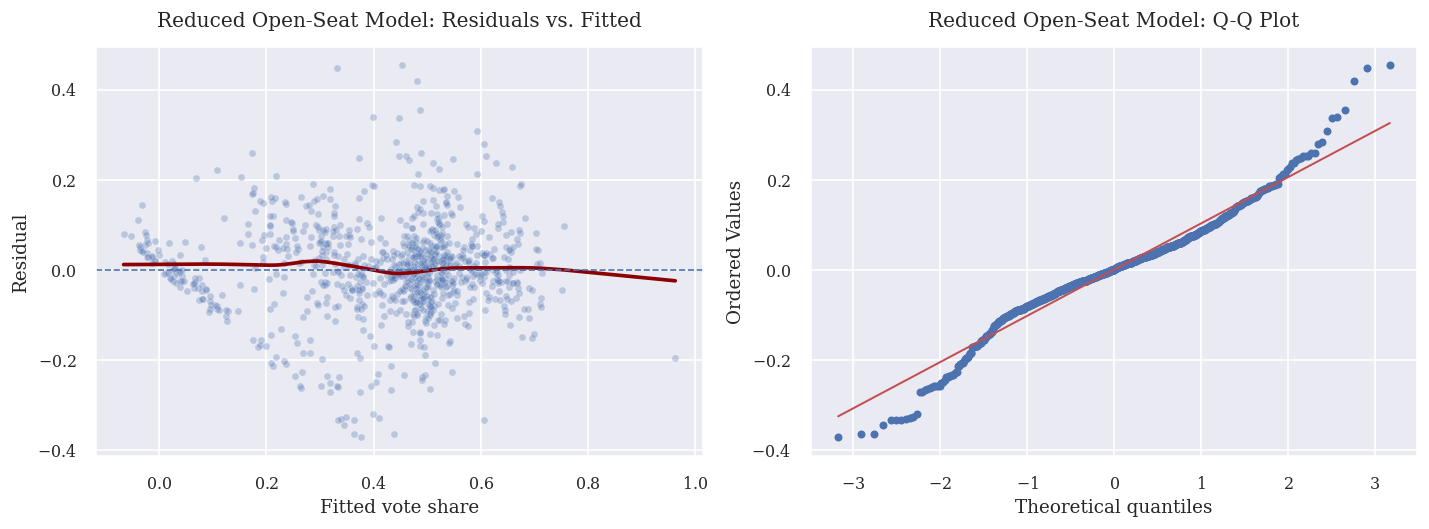

In [55]:
residual_diagnostic_plots(open_reduced, "Reduced Open-Seat Model")

### Kernel Ridge

The linear open-seat model treats the M4 covariates as additive and approximately linear predictors of vote share. Kernel ridge regression relaxes that structure while retaining the same substantive feature set, making it a useful nonlinear extension of the open seat M4 benchmark rather than a separate feature selection exercise.

The comparison below therefore asks whether the same party, campaign finance, and outside spending variables explain additional open-seat vote share variation when modeled more flexibly.

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

krr_features = main_regressors.copy()

X_open = open_reg_df[krr_features].copy()
y_open = open_reg_df["vote_share"].astype(float)

categorical_features = ["party_model"]
numeric_features = [col for col in krr_features if col not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

cv = KFold(n_splits=5, shuffle=True, random_state=577)

In [58]:
linear_ridge = Pipeline([("preprocess", preprocess), ("model", Ridge(alpha=1.0))])
linear_ridge_pred = cross_val_predict(linear_ridge, X_open, y_open, cv=cv)

In [60]:
krr_pipe = Pipeline([("preprocess", preprocess), ("model", KernelRidge(kernel="rbf"))])
krr_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100], "model__gamma": [0.001, 0.01, 0.1, 1]}

krr_search = GridSearchCV(estimator=krr_pipe, param_grid=krr_grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
krr_search.fit(X_open, y_open)

krr_best = krr_search.best_estimator_
krr_search.best_params_

{'model__alpha': 0.01, 'model__gamma': 0.01}

In [62]:
krr_cv_pred = cross_val_predict(krr_search.best_estimator_, X_open, y_open, cv=cv)

def prediction_summary(y_true, y_pred, model_name):
    return pd.DataFrame([{
        "Model": model_name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred)
    }])

open_krr_comparison = pd.concat([
    prediction_summary(y_open, linear_ridge_pred, "Linear ridge benchmark"),
    prediction_summary(y_open, krr_cv_pred, "RBF kernel ridge")
], ignore_index=True)

open_krr_comparison.round(4)

,Model,RMSE,MAE,R²
0,Linear ridge benchmark,0.1058,0.0754,0.7257
1,RBF kernel ridge,0.1007,0.0708,0.7515


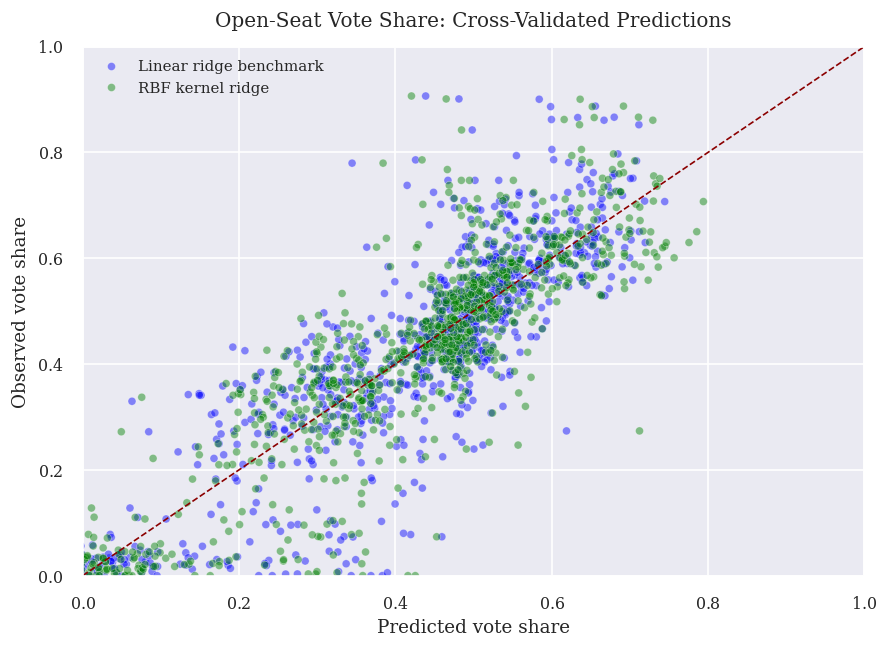

In [65]:
open_krr_pred_df = pd.DataFrame({"Observed vote share": y_open, "Linear ridge benchmark": linear_ridge_pred, "RBF kernel ridge": krr_cv_pred})

open_krr_pred_long = (open_krr_pred_df .melt( id_vars="Observed vote share", value_vars=["Linear ridge benchmark", "RBF kernel ridge"], 
                                             var_name="Model", value_name="Predicted vote share"))

plt.figure(figsize=(7.5, 5.5))

sns.scatterplot(data=open_krr_pred_long, x="Predicted vote share", y="Observed vote share", hue="Model", palette=['blue','green'], alpha=0.45)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="#8B0000")
plt.title("Open-Seat Vote Share: Cross-Validated Predictions", pad=12)
plt.xlabel("Predicted vote share")
plt.ylabel("Observed vote share")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(title="")
plt.tight_layout()
plt.show()

To examine how the kernel ridge model uses campaign receipts, cf. the above partial dependence curve for log total receipts. For each value of log receipts on a grid from the 1st to 99th percentile, I replace the receipt value for every held-out candidate profile while leaving all other covariates fixed, then average the model’s predicted vote share across those profiles. The shaded region shows the interquartile range of predictions across held-out candidate profiles and should be interpreted as heterogeneity across candidate contexts, not as a confidence interval.

The resulting curve is upward sloping but only mildly nonlinear, suggesting that the visibly curved marginal relationship between total receipts and vote share is partly absorbed by other features in the full model, including incumbency, party, finance composition, and outside-spending variables. The wide interquartile band indicates that candidate context remains more important than receipts alone in determining predicted vote share.

### Logistic Regression

In [71]:
logit_cols = [
    "outcome",
    "cycle",
    "party",
    "log1p_ttl_receipts",
    "cash_ratio",
    "indiv_share",
    "other_cmte_share",
    "party_share",
    "itemized_indiv_share",
    "log1p_total_outside_support",
    "log1p_total_outside_oppose",
    "log1p_party_coord_exp"
]

missing_cols = [col for col in logit_cols if col not in house.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

logit_df = house[logit_cols].copy()

logit_df["outcome"] = pd.to_numeric(logit_df["outcome"], errors="raise").astype(int)
logit_df["cycle"] = pd.to_numeric(logit_df["cycle"], errors="raise").astype(int)

logit_df["party_model"] = np.where(
    logit_df["party"].isin(["DEM", "REP"]),
    logit_df["party"],
    "OTH"
)

logit_df["party_model"] = pd.Categorical(
    logit_df["party_model"],
    categories=["OTH", "DEM", "REP"]
)

numeric_logit_cols = [col for col in logit_cols if col not in ["party", "outcome", "cycle"]]

for col in numeric_logit_cols:
    logit_df[col] = pd.to_numeric(logit_df[col], errors="coerce")

logit_df = logit_df.dropna(subset=["outcome", "cycle", "party_model", *numeric_logit_cols]).copy()

logit_formula = (
    "outcome ~ C(party_model) + "
    + " + ".join([x for x in main_regressors if x != "party_model"])
)

logit_cycle_summary = (
    logit_df
    .groupby("cycle")
    .agg(
        n=("outcome", "size"),
        wins=("outcome", "sum"),
        losses=("outcome", lambda x: (x == 0).sum()),
        win_rate=("outcome", "mean")
    )
)

display(logit_cycle_summary.round(3))

logit_df[["outcome"]].describe()



,n,wins,losses,win_rate
cycle,,,,
2004,97,35,62,0.361
2006,69,31,38,0.449
2008,99,38,61,0.384
2010,90,36,54,0.400
2012,80,32,48,0.400
2014,99,38,61,0.384
2016,90,41,49,0.456
2018,126,54,72,0.429
2020,79,33,46,0.418


,outcome
count,926.000000
mean,0.409287
std,0.491968
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [68]:
logit_df["outcome"].value_counts(normalize=True).rename("proportion").to_frame()

,proportion
outcome,
0,0.590713
1,0.409287


In [72]:
from patsy import dmatrices, build_design_matrices

train_df = logit_df[logit_df["cycle"].le(2018)].copy()
test_df = logit_df[logit_df["cycle"].ge(2020)].copy()

y_train_design, X_train_design = dmatrices(logit_formula, data=train_df, return_type="dataframe")
y_train = y_train_design.iloc[:, 0].astype(int)

design_info = X_train_design.design_info

X_test_design = build_design_matrices([design_info], test_df, return_type="dataframe")[0]
y_test = test_df.loc[X_test_design.index, "outcome"].astype(int)

X_train = X_train_design.drop(columns=["Intercept"], errors="ignore")
X_test = X_test_design.drop(columns=["Intercept"], errors="ignore")
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

pd.Series({
    "train_cycles": f"{train_df['cycle'].min()}-{train_df['cycle'].max()}",
    "test_cycles": f"{test_df['cycle'].min()}-{test_df['cycle'].max()}",
    "n_train": len(train_df),
    "n_test": len(test_df),
    "train_win_rate": y_train.mean(),
    "test_win_rate": y_test.mean(),
    "n_features": X_train.shape[1]
})

train_cycles      2004-2018
test_cycles       2020-2022
n_train                 750
n_test                  176
train_win_rate     0.406667
test_win_rate      0.420455
n_features               11
dtype: object

In [73]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    brier_score_loss
)

logit_base = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty=None, solver="lbfgs", max_iter=10000)
)

logit_enet = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0],
        Cs=np.logspace(-3, 3, 25),
        scoring="neg_log_loss",
        cv=KFold(n_splits=5, shuffle=True, random_state=577),
        max_iter=20000,
        random_state=577,
        n_jobs=-1
    )
)

logit_base.fit(X_train, y_train)
logit_enet.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",array([1.0000...00000000e+03])
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0.05, 0.1, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.S

In [74]:
def classification_metrics(model, X, y, sample_name, model_name, threshold=0.5):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)

    return pd.Series({
        "model": model_name,
        "sample": sample_name,
        "threshold": threshold,
        "auc": roc_auc_score(y, prob),
        "log_loss": log_loss(y, prob),
        "brier": brier_score_loss(y, prob),
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0)
    })

logit_metrics = pd.DataFrame([
    classification_metrics(logit_base, X_train, y_train, "train", "Logistic"),
    classification_metrics(logit_base, X_test, y_test, "test", "Logistic"),
    classification_metrics(logit_enet, X_train, y_train, "train", "Elastic-net logistic"),
    classification_metrics(logit_enet, X_test, y_test, "test", "Elastic-net logistic")
])

logit_metrics.round(4)

,model,sample,threshold,auc,log_loss,brier,accuracy,precision,recall,f1
0,Logistic,train,0.5,0.9545,0.2737,0.0832,0.8920,0.8709,0.8623,0.8666
1,Logistic,test,0.5,0.9286,0.3360,0.1138,0.8068,0.8448,0.6622,0.7424
2,Elastic-net logistic,train,0.5,0.9541,0.2777,0.0852,0.8907,0.8680,0.8623,0.8651
3,Elastic-net logistic,test,0.5,0.9296,0.3295,0.1117,0.8125,0.8475,0.6757,0.7519


In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score

def plot_confusion_matrix(model, X, y, model_name, threshold=0.5, normalize=None):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)

    cm = confusion_matrix(y, pred, labels=[0, 1], normalize=normalize)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Loss", "Win"]
    )

    fig, ax = plt.subplots(figsize=(5.5, 5))
    disp.plot(
        ax=ax,
        values_format=".2f" if normalize else "d",
        colorbar=True,
        cmap=plt.cm.viridis
    )

    ax.set_title(f"{model_name}: Confusion Matrix\nTemporal Holdout, threshold = {threshold}")
    plt.show()

    raw_cm = confusion_matrix(y, pred, labels=[0, 1])

    return pd.Series({
        "threshold": threshold,
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "tn": raw_cm[0, 0],
        "fp": raw_cm[0, 1],
        "fn": raw_cm[1, 0],
        "tp": raw_cm[1, 1]
    })

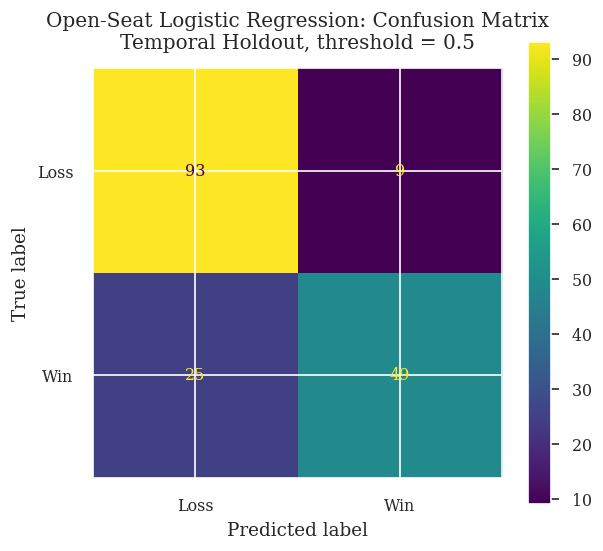

threshold             0.5000
accuracy              0.8068
balanced_accuracy     0.7870
precision             0.8448
recall                0.6622
f1                    0.7424
tn                   93.0000
fp                    9.0000
fn                   25.0000
tp                   49.0000
dtype: float64

In [76]:
logit_base_cm_metrics = plot_confusion_matrix(logit_base, X_test, y_test, "Open-Seat Logistic Regression", threshold=0.5)

logit_base_cm_metrics.round(4)

In [78]:
enet_logit_model = logit_enet.named_steps["logisticregressioncv"]

enet_logit_summary = pd.Series({
    "best_C": enet_logit_model.C_[0],
    "best_l1_ratio": enet_logit_model.l1_ratio_[0],
    "n_features": X_train.shape[1],
    "n_nonzero_coefs": (enet_logit_model.coef_[0] != 0).sum()
})

enet_logit_coefs = (pd.DataFrame({"feature": X_train.columns, "standardized_coef": enet_logit_model.coef_[0]}).assign(abs_coef=lambda x: x["standardized_coef"].abs()) 
                    .sort_values("abs_coef", ascending=False))

display(enet_logit_summary)
display(enet_logit_coefs.round(4))

best_C              0.316228
best_l1_ratio       1.000000
n_features         11.000000
n_nonzero_coefs     9.000000
dtype: float64

,feature,standardized_coef,abs_coef
2,log1p_ttl_receipts,3.1655,3.1655
9,log1p_total_outside_oppose,-1.5132,1.5132
5,other_cmte_share,1.2239,1.2239
3,cash_ratio,0.5717,0.5717
1,C(party_model)[T.REP],0.5179,0.5179
7,itemized_indiv_share,0.3808,0.3808
6,party_share,-0.1647,0.1647
8,log1p_total_outside_support,0.1093,0.1093
10,log1p_party_coord_exp,-0.0268,0.0268
0,C(party_model)[T.DEM],0.0000,0.0000


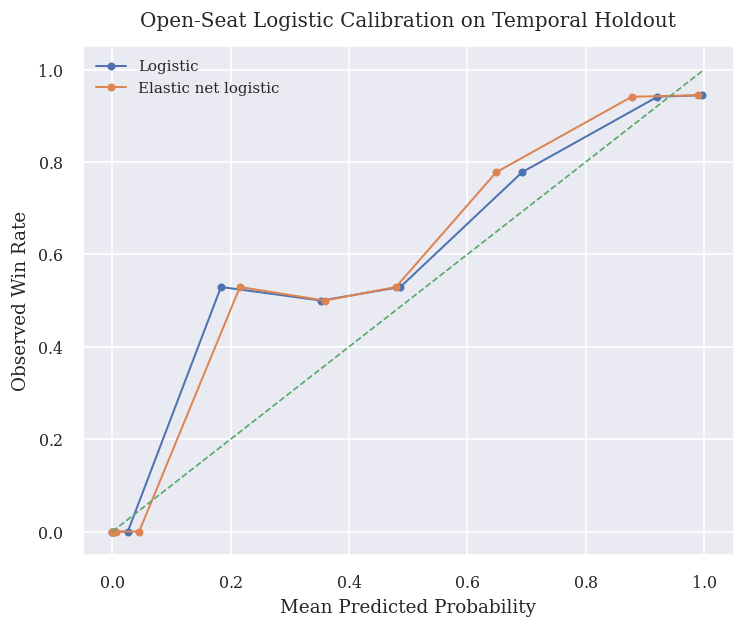

In [81]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(7, 5.5))

for model, label in [
    (logit_base, "Logistic"),
    (logit_enet, "Elastic net logistic")
]:
    prob = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(
        y_test,
        prob,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(mean_pred, frac_pos, marker="o", label=label)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("Open-Seat Logistic Calibration on Temporal Holdout", pad=12)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Win Rate")
plt.legend()
plt.show()

As a bridge between the vote-share regression models and the binary classification models, I also include a KRLS-style kernel ridge model below as a classifier-by-proxy. Unlike the direct classifiers below, this model is trained on vote share rather than the binary win/loss outcome. Its predicted vote share is then treated as a classification score, with predicted victory assigned whenever the predicted vote share is at least 0.5.

This benchmark is of potential interest because it asks whether modeling the electoral margin first can recover winners as well as models trained directly on the win/loss target. The comparison is therefore not purely algorithmic: It contrasts a margin-first electoral model with direct classification models. AUC, accuracy, precision, recall, and F1 are comparable as classification diagnostics, while log loss and Brier score should be read cautiously because predicted vote share is not the same object as a calibrated win probability.

In [84]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, GroupKFold

krr_cols = [
    "vote_share",
    "outcome",
    "cycle",
    "party",
    "log1p_ttl_receipts",
    "cash_ratio",
    "indiv_share",
    "other_cmte_share",
    "party_share",
    "itemized_indiv_share",
    "log1p_total_outside_support",
    "log1p_total_outside_oppose",
    "log1p_party_coord_exp"
]

missing_cols = [col for col in krr_cols if col not in house.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

krr_df = house[krr_cols].copy()

krr_df["cycle"] = pd.to_numeric(krr_df["cycle"], errors="raise").astype(int)
krr_df["outcome"] = pd.to_numeric(krr_df["outcome"], errors="raise").astype(int)

krr_df["party_model"] = np.where(
    krr_df["party"].isin(["DEM", "REP"]),
    krr_df["party"],
    "OTH"
)

krr_df["party_model"] = pd.Categorical(
    krr_df["party_model"],
    categories=["OTH", "DEM", "REP"]
)

krr_numeric_cols = [col for col in krr_cols if col not in ["party", "outcome", "cycle"]]

for col in krr_numeric_cols:
    krr_df[col] = pd.to_numeric(krr_df[col], errors="coerce")

krr_df = krr_df.dropna(subset=["vote_share", "outcome", "cycle", "party_model", *[col for col in krr_numeric_cols if col != "vote_share"]]).copy()

krr_formula = (
    "vote_share ~ C(party_model) + "
    + " + ".join([x for x in main_regressors if x != "party_model"])
)

krr_train_df = krr_df[krr_df["cycle"].le(2018)].copy()
krr_test_df = krr_df[krr_df["cycle"].ge(2020)].copy()

y_krr_train_design, X_krr_train_design = dmatrices(krr_formula, data=krr_train_df, return_type="dataframe")
krr_design_info = X_krr_train_design.design_info

X_krr_test_design = build_design_matrices([krr_design_info], krr_test_df, return_type="dataframe")[0]

X_krr_train = X_krr_train_design.drop(columns=["Intercept"], errors="ignore")
X_krr_test = X_krr_test_design.drop(columns=["Intercept"], errors="ignore").reindex(columns=X_krr_train.columns, fill_value=0)

y_krr_train_vote = y_krr_train_design.iloc[:, 0]
y_krr_test_vote = krr_test_df.loc[X_krr_test.index, "vote_share"]

y_krr_train_class = krr_train_df.loc[X_krr_train.index, "outcome"].astype(int)
y_krr_test_class = krr_test_df.loc[X_krr_test.index, "outcome"].astype(int)

krr_pipe = make_pipeline(
    StandardScaler(),
    KernelRidge(kernel="rbf")
)

krr_grid = {
    "kernelridge__alpha": [0.01, 0.1, 1, 10],
    "kernelridge__gamma": [0.005, 0.01, 0.025, 0.05, 0.1]
}

krr_cv = GridSearchCV(
    krr_pipe,
    krr_grid,
    scoring="neg_root_mean_squared_error",
    cv=GroupKFold(n_splits=5),
    n_jobs=-1
)

krr_cv.fit(
    X_krr_train,
    y_krr_train_vote,
    groups=krr_train_df.loc[X_krr_train.index, "cycle"]
)

krr_train_prob = np.clip(krr_cv.predict(X_krr_train), 1e-6, 1 - 1e-6)
krr_test_prob = np.clip(krr_cv.predict(X_krr_test), 1e-6, 1 - 1e-6)

pd.Series({
    "best_alpha": krr_cv.best_params_["kernelridge__alpha"],
    "best_gamma": krr_cv.best_params_["kernelridge__gamma"],
    "train_vote_share_rmse": mean_squared_error(y_krr_train_vote, krr_train_prob) ** 0.5,
    "test_vote_share_rmse": mean_squared_error(y_krr_test_vote, krr_test_prob) ** 0.5
}).round(4)

best_alpha               0.1000
best_gamma               0.0100
train_vote_share_rmse    0.0900
test_vote_share_rmse     0.1209
dtype: float64

In [85]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

classifiers = {
    "Logistic": logit_base,

    "Elastic-net logistic": logit_enet,

    "Random forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=577,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=577,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=15,
        min_samples_leaf=20,
        l2_regularization=0.1,
        random_state=577
    ),

    "MLP": make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(64, 32, 16),
            activation="relu",
            alpha=0.001,
            learning_rate_init=0.001,
            early_stopping=True,
            validation_fraction=0.15,
            max_iter=2000,
            random_state=577
        )
    )
}

ml_results = []

for name, model in classifiers.items():
    model.fit(X_train, y_train)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    for sample, y, prob in [
        ("train", y_train, train_prob),
        ("test", y_test, test_prob)
    ]:
        pred = (prob >= 0.5).astype(int)

        ml_results.append({
            "model": name,
            "sample": sample,
            "auc": roc_auc_score(y, prob),
            "log_loss": log_loss(y, prob),
            "brier": brier_score_loss(y, prob),
            "accuracy": accuracy_score(y, pred),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0)
        })

for sample, y, prob in [
    ("train", y_krr_train_class, krr_train_prob),
    ("test", y_krr_test_class, krr_test_prob)
]:
    pred = (prob >= 0.5).astype(int)

    ml_results.append({
        "model": "KRLS-style KRR vote-share proxy",
        "sample": sample,
        "auc": roc_auc_score(y, prob),
        "log_loss": log_loss(y, prob),
        "brier": brier_score_loss(y, prob),
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0)
    })

ml_results = pd.DataFrame(ml_results)

ml_results.round(4)

,model,sample,auc,log_loss,brier,accuracy,precision,recall,f1
0,Logistic,train,0.9545,0.2737,0.0832,0.8920,0.8709,0.8623,0.8666
1,Logistic,test,0.9286,0.3360,0.1138,0.8068,0.8448,0.6622,0.7424
2,Elastic-net logistic,train,0.9541,0.2777,0.0852,0.8907,0.8680,0.8623,0.8651
3,Elastic-net logistic,test,0.9296,0.3295,0.1117,0.8125,0.8475,0.6757,0.7519
4,Random forest,train,0.9800,0.2519,0.0702,0.9173,0.8984,0.8984,0.8984
5,Random forest,test,0.9367,0.3397,0.1080,0.8523,0.8529,0.7838,0.8169
6,ExtraTrees,train,0.9582,0.3664,0.1098,0.8853,0.8687,0.8459,0.8571
7,ExtraTrees,test,0.9393,0.3886,0.1217,0.8352,0.8571,0.7297,0.7883
8,HistGradientBoosting,train,1.0000,0.0131,0.0007,1.0000,1.0000,1.0000,1.0000
9,HistGradientBoosting,test,0.9357,0.4372,0.1225,0.8409,0.8382,0.7703,0.8028


In [86]:
ml_results[ml_results["sample"].eq("test")].sort_values( by=["accuracy", "precision", "recall"], ascending=[False, False, False]).round(4)

,model,sample,auc,log_loss,brier,accuracy,precision,recall,f1
5,Random forest,test,0.9367,0.3397,0.1080,0.8523,0.8529,0.7838,0.8169
9,HistGradientBoosting,test,0.9357,0.4372,0.1225,0.8409,0.8382,0.7703,0.8028
7,ExtraTrees,test,0.9393,0.3886,0.1217,0.8352,0.8571,0.7297,0.7883
3,Elastic-net logistic,test,0.9296,0.3295,0.1117,0.8125,0.8475,0.6757,0.7519
1,Logistic,test,0.9286,0.3360,0.1138,0.8068,0.8448,0.6622,0.7424
13,KRLS-style KRR vote-share proxy,test,0.9188,0.4984,0.1621,0.7955,0.9130,0.5676,0.7000
11,MLP,test,0.9177,0.4044,0.1320,0.7841,0.8214,0.6216,0.7077


One striking difference from the preliminary analysis is the marked deterioration of the multilayer perceptron in the open-seat setting. In the full candidate sample, the MLP performed competitively, likely benefiting from the larger sample and the strong predictive structure introduced by incumbency. Once the analysis is restricted to open-seat races, however, the classification problem becomes smaller and more delicate. The MLP’s poor performance therefore suggests that the full-sample neural-network result may have depended heavily on broad, easily learned structure that does not carry over once incumbency is removed.

By contrast, the random forest remains a clear frontrunner in the open-seat subset, especially after threshold adjustment and when fit on the prelim-reduced feature set (see below). This contrast reinforces the usefulness of simpler, more stable ensemble methods for this stage of the analysis.

In [106]:
from sklearn.inspection import permutation_importance

def feature_block_label(feature):
    if feature.startswith("C(party_model)"):
        return "party"
    if feature == "log1p_ttl_receipts":
        return "scale"
    if feature in [
        "cash_ratio",
        "indiv_share",
        "other_cmte_share",
        "party_share",
        "itemized_indiv_share"
    ]:
        return "composition"
    if feature in [
        "log1p_total_outside_support",
        "log1p_total_outside_oppose",
        "log1p_party_coord_exp"
    ]:
        return "outside"
    return "other"

importance_models = {
    "Random forest": classifiers["Random forest"],
    "ExtraTrees": classifiers["ExtraTrees"],
    "HistGradientBoosting": classifiers["HistGradientBoosting"],
    "MLP": classifiers["MLP"]
}

importance_rows = []

for model_name, model in importance_models.items():
    model.fit(X_train, y_train)

    result = permutation_importance(
        model,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=577,
        n_jobs=-1
    )

    importance_rows.append(
        pd.DataFrame({
            "model": model_name,
            "feature": X_test.columns,
            "importance_mean": result.importances_mean,
            "importance_sd": result.importances_std
        })
    )

importance_table = pd.concat(importance_rows, ignore_index=True)
importance_table["block"] = importance_table["feature"].map(feature_block_label)

importance_by_feature = (
    importance_table
    .sort_values(
        ["model", "importance_mean"],
        ascending=[True, False]
    )
)

importance_by_block = (
    importance_table
    .groupby(["model", "block"], as_index=False)
    .agg(
        importance_mean=("importance_mean", "sum"),
        importance_sd=("importance_sd", "mean")
    )
    .sort_values(
        ["model", "importance_mean"],
        ascending=[True, False]
    )
)

display(importance_by_block.round(4))
display(importance_by_feature.round(4))

,model,block,importance_mean,importance_sd
3,ExtraTrees,scale,0.0776,0.0209
1,ExtraTrees,outside,0.0543,0.0071
0,ExtraTrees,composition,0.0517,0.0052
2,ExtraTrees,party,0.0270,0.0070
7,HistGradientBoosting,scale,0.1553,0.0299
4,HistGradientBoosting,composition,0.0779,0.0071
5,HistGradientBoosting,outside,0.0500,0.0051
6,HistGradientBoosting,party,0.0048,0.0028
8,MLP,composition,0.0745,0.0086
11,MLP,scale,0.0728,0.0201


,model,feature,importance_mean,importance_sd,block
13,ExtraTrees,log1p_ttl_receipts,0.0776,0.0209,scale
20,ExtraTrees,log1p_total_outside_oppose,0.0481,0.0117,outside
16,ExtraTrees,other_cmte_share,0.0374,0.0134,composition
12,ExtraTrees,C(party_model)[T.REP],0.0237,0.0114,party
14,ExtraTrees,cash_ratio,0.0132,0.0037,composition
19,ExtraTrees,log1p_total_outside_support,0.0065,0.0073,outside
18,ExtraTrees,itemized_indiv_share,0.0035,0.0046,composition
11,ExtraTrees,C(party_model)[T.DEM],0.0033,0.0027,party
21,ExtraTrees,log1p_party_coord_exp,-0.0003,0.0023,outside
17,ExtraTrees,party_share,-0.0006,0.0017,composition


### Random Forest Classifier

In [93]:
rf_model = classifiers["Random forest"]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

threshold_rows = []

for threshold in np.arange(0.35, 0.66, 0.05):
    pred = (rf_prob >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "specificity": 2 * balanced_accuracy_score(y_test, pred) - recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred)
    })

rf_threshold_table = pd.DataFrame(threshold_rows)

rf_threshold_table.round(4)

,threshold,accuracy,precision,recall,specificity,f1,balanced_accuracy
0,0.35,0.8750,0.8023,0.9324,0.8333,0.8625,0.8829
1,0.40,0.8636,0.8289,0.8514,0.8725,0.8400,0.8620
2,0.45,0.8636,0.8378,0.8378,0.8824,0.8378,0.8601
3,0.50,0.8523,0.8529,0.7838,0.9020,0.8169,0.8429
4,0.55,0.8182,0.8500,0.6892,0.9118,0.7612,0.8005
5,0.60,0.7784,0.8302,0.5946,0.9118,0.6929,0.7532
6,0.65,0.7670,0.8837,0.5135,0.9510,0.6496,0.7322


In [103]:
rf_pred = (rf_prob >= 0.5).astype(int)

rf_error_df = test_df.loc[X_test.index].copy()
rf_error_df["vote_share"] = pd.to_numeric(house.loc[rf_error_df.index, "vote_share"], errors="coerce")
rf_error_df["rf_prob"] = rf_prob
rf_error_df["rf_pred"] = rf_pred

rf_error_df["error_type"] = np.select(
    [
        (y_test.eq(1) & (rf_pred == 0)),
        (y_test.eq(0) & (rf_pred == 1)),
        (y_test.eq(1) & (rf_pred == 1)),
        (y_test.eq(0) & (rf_pred == 0))
    ],
    ["false_negative", "false_positive", "true_positive", "true_negative"],
    default="unknown"
)

rf_error_summary = (
    rf_error_df
    .dropna(subset=["vote_share"])
    .groupby("error_type")
    .agg(
        n=("outcome", "size"),
        mean_vote_share=("vote_share", "mean"),
        median_vote_share=("vote_share", "median"),
        mean_rf_prob=("rf_prob", "mean")
    )
)

rf_error_summary.round(4)

,n,mean_vote_share,median_vote_share,mean_rf_prob
error_type,,,,
false_negative,16,0.5807,0.5412,0.3758
false_positive,10,0.4172,0.4556,0.6759
true_negative,92,0.2982,0.3392,0.1139
true_positive,58,0.6236,0.6127,0.7291


In [104]:
rf_pred = (rf_prob >= 0.35).astype(int)

rf_error_df = test_df.loc[X_test.index].copy()
rf_error_df["vote_share"] = pd.to_numeric(house.loc[rf_error_df.index, "vote_share"], errors="coerce")
rf_error_df["rf_prob"] = rf_prob
rf_error_df["rf_pred"] = rf_pred

rf_error_df["error_type"] = np.select(
    [
        (y_test.eq(1) & (rf_pred == 0)),
        (y_test.eq(0) & (rf_pred == 1)),
        (y_test.eq(1) & (rf_pred == 1)),
        (y_test.eq(0) & (rf_pred == 0))
    ],
    ["false_negative", "false_positive", "true_positive", "true_negative"],
    default="unknown"
)

rf_error_summary = (
    rf_error_df
    .dropna(subset=["vote_share"])
    .groupby("error_type")
    .agg(
        n=("outcome", "size"),
        mean_vote_share=("vote_share", "mean"),
        median_vote_share=("vote_share", "median"),
        mean_rf_prob=("rf_prob", "mean")
    )
)

rf_error_summary.round(4)

,n,mean_vote_share,median_vote_share,mean_rf_prob
error_type,,,,
false_negative,5,0.5277,0.5314,0.2762
false_positive,17,0.4170,0.4518,0.5634
true_negative,85,0.2884,0.3360,0.0901
true_positive,69,0.6206,0.6011,0.6800


In [96]:
rf_model = classifiers["Random forest"]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_band_df = test_df.loc[X_test.index].copy()
rf_band_df["vote_share"] = pd.to_numeric(house.loc[rf_band_df.index, "vote_share"], errors="coerce")
rf_band_df["rf_prob"] = rf_prob

rf_band_df["prob_band"] = pd.cut(
    rf_band_df["rf_prob"],
    bins=[0, 0.25, 0.35, 0.50, 0.65, 0.75, 1],
    include_lowest=True
)

rf_band_summary = (
    rf_band_df
    .dropna(subset=["vote_share"])
    .groupby("prob_band", observed=True)
    .agg(
        n=("outcome", "size"),
        wins=("outcome", "sum"),
        win_rate=("outcome", "mean"),
        mean_vote_share=("vote_share", "mean"),
        median_vote_share=("vote_share", "median"),
        mean_rf_prob=("rf_prob", "mean")
    )
)

rf_band_summary.round(4)

,n,wins,win_rate,mean_vote_share,median_vote_share,mean_rf_prob
prob_band,,,,,,
"(-0.001, 0.25]",78,1,0.0128,0.2747,0.3163,0.0707
"(0.25, 0.35]",12,4,0.3333,0.4773,0.4713,0.2936
"(0.35, 0.5]",18,11,0.6111,0.5317,0.5160,0.4139
"(0.5, 0.65]",25,20,0.8000,0.5262,0.5292,0.5790
"(0.65, 0.75]",13,9,0.6923,0.5864,0.6258,0.6895
"(0.75, 1.0]",30,29,0.9667,0.6520,0.6329,0.8536


In [97]:
for threshold in [0.35, 0.50]:
    pred = (rf_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])

    print(f"\nThreshold = {threshold}")
    print(pd.DataFrame(
        cm,
        index=["Actual loss", "Actual win"],
        columns=["Predicted loss", "Predicted win"]
    ))


Threshold = 0.35
             Predicted loss  Predicted win
Actual loss              85             17
Actual win                5             69

Threshold = 0.5
             Predicted loss  Predicted win
Actual loss              92             10
Actual win               16             58


Unexpectedly, it was found that lowering the random-forest classification threshold from 0.50 to 0.35 concomitantly substantially increased accuracy and recall with only a modest loss in precision. This appears to reflect conservative probability scores rather than a clearly superior universal threshold: Several mid-probability bands have observed win rates above their mean predicted probabilities, while some smaller bands are noisy. 

In [99]:
from sklearn.model_selection import cross_val_predict, GroupKFold

rf_for_threshold = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=577,
    n_jobs=-1
)

train_groups = train_df.loc[X_train.index, "cycle"]

rf_train_oof_prob = cross_val_predict(
    rf_for_threshold,
    X_train,
    y_train,
    cv=GroupKFold(n_splits=5),
    groups=train_groups,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_rows = []

for threshold in np.arange(0.20, 0.71, 0.01):
    pred = (rf_train_oof_prob >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_train, pred),
        "precision": precision_score(y_train, pred, zero_division=0),
        "recall": recall_score(y_train, pred, zero_division=0),
        "f1": f1_score(y_train, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_train, pred)
    })

rf_train_threshold_table = pd.DataFrame(threshold_rows)

rf_train_threshold_table.sort_values("f1", ascending=False).head(10).round(4)

,threshold,accuracy,precision,recall,f1,balanced_accuracy
25,0.45,0.8733,0.8221,0.8787,0.8494,0.8742
26,0.46,0.8733,0.8261,0.8721,0.8485,0.8731
19,0.39,0.8640,0.7812,0.9246,0.8468,0.8735
24,0.44,0.8693,0.8108,0.8852,0.8464,0.8718
23,0.43,0.8680,0.8047,0.8918,0.8460,0.8717
16,0.36,0.8560,0.7572,0.9508,0.8430,0.8709
20,0.40,0.8613,0.7831,0.9115,0.8424,0.8692
18,0.38,0.8573,0.7661,0.9344,0.8419,0.8695
22,0.42,0.8627,0.7936,0.8951,0.8413,0.8678
28,0.48,0.8693,0.8350,0.8459,0.8404,0.8656


In [100]:
best_rf_threshold = rf_train_threshold_table.loc[
    rf_train_threshold_table["f1"].idxmax(),
    "threshold"
]

rf_model = classifiers["Random forest"]
rf_model.fit(X_train, y_train)

rf_test_prob = rf_model.predict_proba(X_test)[:, 1]
rf_test_pred = (rf_test_prob >= best_rf_threshold).astype(int)

pd.Series({
    "selected_threshold": best_rf_threshold,
    "test_accuracy": accuracy_score(y_test, rf_test_pred),
    "test_precision": precision_score(y_test, rf_test_pred, zero_division=0),
    "test_recall": recall_score(y_test, rf_test_pred, zero_division=0),
    "test_f1": f1_score(y_test, rf_test_pred, zero_division=0),
    "test_balanced_accuracy": balanced_accuracy_score(y_test, rf_test_pred)
}).round(4)

selected_threshold        0.4500
test_accuracy             0.8636
test_precision            0.8378
test_recall               0.8378
test_f1                   0.8378
test_balanced_accuracy    0.8601
dtype: float64

The threshold-sensitivity results are suggestive of a potentially meaningful calibration issue, namely that the random forest's default 0.50 cutoff is somewhat conservative in the open-seat holdout. A direct sweep over the test set gives its strongest recall and overall accuracy at a lower threshold of 0.35, but this threshold is necessarily post hoc. To check whether the result merely reflects holdout-specific noise, we selected the classification threshold using out-of-fold predictions from the training cycles only. This procedure selected a threshold of 0.45, which falls between the conventional 0.50 cutoff and the test-set-favorable 0.35 cutoff.

This result tempers but does not erase the substantive finding. The evidence does not justify treating 0.35 as a stable universal threshold, but it does suggest that the random forest's probability scores are somewhat compressed downward for winning open-seat candidates. In this setting, a mildly lower threshold improves winner detection without requiring a different feature set or a more elaborate model search. 

In [ ]:
rf_feature_sets = {
    "Full RF": list(X_train.columns),

    "Prelim-reduced RF": [
        col for col in X_train.columns
        if (
            col.startswith("C(party_model)")
            or col in [
                "log1p_ttl_receipts",
                "cash_ratio",
                "other_cmte_share",
                "log1p_total_outside_support",
                "log1p_total_outside_oppose"
            ]
        )
    ],

    "Permutation-positive RF": (
        importance_table[
            importance_table["model"].eq("Random forest")
            & importance_table["importance_mean"].gt(0)
        ]["feature"]
        .tolist()
    )
}

rf_reduced_results = []

for name, features in rf_feature_sets.items():
    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=577,
        n_jobs=-1
    )

    model.fit(X_train[features], y_train)

    train_prob = model.predict_proba(X_train[features])[:, 1]
    test_prob = model.predict_proba(X_test[features])[:, 1]

    for sample, y, prob in [
        ("train", y_train, train_prob),
        ("test", y_test, test_prob)
    ]:
        pred = (prob >= 0.5).astype(int)

        rf_reduced_results.append({
            "model": name,
            "sample": sample,
            "n_features": len(features),
            "auc": roc_auc_score(y, prob),
            "log_loss": log_loss(y, prob),
            "brier": brier_score_loss(y, prob),
            "accuracy": accuracy_score(y, pred),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y, pred)
        })

rf_reduced_results = pd.DataFrame(rf_reduced_results)

rf_reduced_results.round(4)

,model,sample,n_features,auc,log_loss,brier,accuracy,precision,recall,f1,balanced_accuracy
0,Full RF,train,11,0.9800,0.2519,0.0702,0.9173,0.8984,0.8984,0.8984,0.9143
1,Full RF,test,11,0.9367,0.3397,0.1080,0.8523,0.8529,0.7838,0.8169,0.8429
2,Prelim-reduced RF,train,7,0.9759,0.2609,0.0748,0.9147,0.8875,0.9049,0.8961,0.9131
3,Prelim-reduced RF,test,7,0.9469,0.3266,0.1018,0.8750,0.8824,0.8108,0.8451,0.8662
4,Permutation-positive RF,train,6,0.9771,0.2502,0.0712,0.9187,0.8910,0.9115,0.9011,0.9175
5,Permutation-positive RF,test,6,0.9489,0.3267,0.1024,0.8239,0.8772,0.6757,0.7634,0.8035


In [108]:
rf_reduced_threshold_results = []

for name, features in rf_feature_sets.items():
    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=577,
        n_jobs=-1
    )

    model.fit(X_train[features], y_train)
    test_prob = model.predict_proba(X_test[features])[:, 1]
    pred = (test_prob >= best_rf_threshold).astype(int)

    rf_reduced_threshold_results.append({
        "model": name,
        "threshold": best_rf_threshold,
        "n_features": len(features),
        "auc": roc_auc_score(y_test, test_prob),
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred)
    })

rf_reduced_threshold_results = pd.DataFrame(rf_reduced_threshold_results)

rf_reduced_threshold_results.round(4)

,model,threshold,n_features,auc,accuracy,precision,recall,f1,balanced_accuracy
0,Full RF,0.45,11,0.9367,0.8636,0.8378,0.8378,0.8378,0.8601
1,Prelim-reduced RF,0.45,7,0.9469,0.8920,0.8571,0.8919,0.8742,0.8920
2,Permutation-positive RF,0.45,6,0.9489,0.8750,0.8714,0.8243,0.8472,0.8680


As a final sensitivity check, we compared the full random forest against two reduced variants: One using the reduced feature set motivated by the preliminary analysis, and another using only the variables with positive permutation importance in the open-seat holdout. The results strongly favor the more principled approach. The prelim-reduced random forest preserves essentially all of the predictive performance of the full model, while the post hoc permutation-positive subset produces marked degradation in performance.

This is a useful modeling check. The permutation table is valuable diagnostically, since it shows that the random forest's signal is concentrated in a small number of finance variables. But it is not, by itself, a clean basis for refitting and selecting a new model, especially when the permutation importances are computed on the temporal holdout. By contrast, the prelim-reduced feature set is externally motivated by the earlier modeling sequence and therefore provides a cleaner robustness check.

The result supports the broader interpretation of the open-seat analysis: The predictive structure is not an artifact of a large, overstuffed feature set. A compact group of substantively motivated variables, especially campaign scale, cash ratio, other committee support, and outside spending, carries much of the signal even after incumbency has been removed.

Finally, the threshold calibration issue noted above is seemingly reinforced by this final sensitivity check. Our random forest evaluated at the training-selected 0.45 threshold noted above gains noticeably from passing to the prelim-reduced feature set, achieving accuracy and recall within a few points of the high-performing preliminary classifiers fit on the full candidate sample, to which incumbency was still available as a predictor. This provides an interesting and potentially useful concluding result: *The open-seat models recover much of the predictive power observed in the full-sample analysis using only a compact subset of campaign finance variables.* The result suggests that the finance structure identified above is not merely a proxy for incumbency, but remains informative in races where the incumbency advantage has been removed entirely.